In [102]:
# 1

# I am importing NumPy because we will need it for mathematical operations,
# such as creating vectors, matrices, doing modular arithmetic, etc.
import numpy as np

# I import 'QuantumCircuit' because it lets me build custom quantum circuits in Qiskit.
from qiskit import QuantumCircuit

# I import 'ClassicalRegister' because I need classical bits to store measurement outcomes.
from qiskit import ClassicalRegister

# I import 'QuantumRegister' because I want explicit control over qudit-like qubit registers.
from qiskit import QuantumRegister

# I import the AerSimulator to simulate noisy and ideal quantum computations locally.
from qiskit_aer import AerSimulator

# I import 'transpile' because Qiskit requires circuits to be adapted to a backend before execution.
from qiskit import transpile

# I import 'matplotlib.pyplot' because I will create many plots (threshold curves, scaling graphs, etc.)
import matplotlib.pyplot as plt

# I import 'itertools' because I will use it to iterate over combinations and repeated structures.
import itertools

In [103]:
# 2

# This function creates the generalized qudit Z operator for dimension d.
# The Z_d operator acts as: |k> -> ω^k |k>, where ω = exp(2πi/d).
def qudit_Z_matrix(d):
    # I create the complex phase ω used in qudit algebra.
    omega = np.exp(2j * np.pi / d)

    # I build a diagonal matrix of size dxd, where each diagonal entry is ω^k.
    # This is the standard definition of Z_d in qudit systems.
    Z = np.diag([omega**k for k in range(d)])

    # I return the matrix so later we can use it in noise models or debugging.
    return Z


# This function creates the generalized qudit X operator for dimension d.
# The X_d operator cyclically shifts basis states: |k> -> |k+1 mod d|.
def qudit_X_matrix(d):
    # I start by creating a zero matrix of shape dxd.
    X = np.zeros((d, d), dtype=complex)

    # I fill the matrix so that X[k, k-1] = 1, implementing cyclic shift.
    for k in range(d):
        # This modulo operation ensures wrap-around, so |d-1> -> |0>.
        X[k, (k - 1) % d] = 1

    # Return the permutation matrix representing X_d.
    return X


# This function generates the generalized qudit Fourier transform F_d.
# This operator maps |k> to (1/sqrt(d)) Σ_j ω^(j*k) |j>.
def qudit_fourier_matrix(d):
    # Create the base complex phase ω.
    omega = np.exp(2j * np.pi / d)

    # Initialize an empty matrix.
    F = np.zeros((d, d), dtype=complex)

    # Fill the matrix using the Fourier formula.
    for j in range(d):
        for k in range(d):
            # Assign ω^(j*k) normalized by sqrt(d).
            F[j, k] = omega ** (j * k) / np.sqrt(d)

    # Return the Fourier transform matrix.
    return F

In [104]:
# 3

# This function converts a qudit state (value between 0 and d-1) into its binary representation.
# We need this because Qiskit only supports qubits, so we encode qudits using log2(d) qubits.
def qudit_state_to_qubits(value, d):
    # I compute how many qubits are required to represent values from 0 to d-1.
    num_qubits = int(np.ceil(np.log2(d)))

    # I convert the number into binary, padded to the correct number of qubits.
    # Example: for d=4, value=2 → [1, 0].
    binary = list(map(int, np.binary_repr(value, width=num_qubits)))

    # I return the list (most significant bit first).
    return binary

In [105]:
# 4

# This function builds the stabilizers of a qudit repetition code of distance n.
# For qubit (d=2) repetition code, stabilizers are Z₁Z₂, Z₂Z₃, ..., Z_{n-1}Z_n.
# For qudits, stabilizers generalize to Z_d ⊗ Z_d^†.
def build_qudit_repetition_stabilizers(n, d):
    # I create an empty list to hold all stabilizers.
    # Each stabilizer will be represented as a pair of X/Z matrices.
    stabilizers = []

    # For a repetition code, stabilizers act on adjacent qudits.
    for i in range(n - 1):
        # I create identity operators for all qudits.
        ops = ["I"] * n

        # I assign Z_d to qudit i.
        ops[i] = "Z"

        # I assign Z_d† (inverse) to qudit i+1.
        ops[i+1] = "Zdg"

        # I append the stabilizer to the list.
        stabilizers.append(ops)

    # Return the whole stabilizer list.
    return stabilizers

In [106]:
# 5

# This function generates the syndrome measurement circuit for a qudit repetition code.
# It uses qubit registers to "simulate" qudits, storing syndrome outcomes classically.
def generate_qudit_repetition_syndrome_circuit(n, d):
    # First, I compute how many qubits are needed to encode one qudit.
    qubits_per_qudit = int(np.ceil(np.log2(d)))

    # I compute the total number of qubits required.
    total_qubits = n * qubits_per_qudit

    # I create a quantum register for all qubits in the code.
    qreg = QuantumRegister(total_qubits, "data")

    # I create a classical register to store measurement outcomes.
    creg = ClassicalRegister((n - 1) * qubits_per_qudit, "syndrome")

    # I now initialize the circuit with the registers.
    qc = QuantumCircuit(qreg, creg)

    # I loop over each stabilizer (there are n-1 stabilizers).
    for s in range(n - 1):
        # I compute the starting qubit index for qudit s.
        q1 = s * qubits_per_qudit

        # And also the starting index for qudit s+1.
        q2 = (s + 1) * qubits_per_qudit

        # I now apply CNOTs between corresponding binary-encoded bits
        # of qudit s and qudit s+1 as a proxy for Z ⊗ Z† stabilizers.
        for b in range(qubits_per_qudit):
            # Apply CNOT from bit b of qudit s to bit b of qudit s+1.
            qc.cx(qreg[q1 + b], qreg[q2 + b])

            # Measure the syndrome into the classical register.
            qc.measure(qreg[q2 + b], creg[s * qubits_per_qudit + b])

    # Finally, I return the entire syndrome extraction circuit.
    return qc

In [107]:
# 6

# This function creates a generalized depolarizing noise channel for a qudit.
# In qubit systems, depolarizing noise sends ρ → (1-p)ρ + p * I/2.
# For qudits, it becomes ρ → (1-p)ρ + p * I/d.
def qudit_depolarizing_channel(rho, p, d):
    # I first compute the identity matrix of size dxd.
    I = np.eye(d, dtype=complex)

    # I compute the completely mixed state I/d.
    mixed = I / d

    # Now I apply the generalized depolarizing formula.
    noisy_rho = (1 - p) * rho + p * mixed

    # I return the resulting density matrix.
    return noisy_rho

In [108]:
# 7

# This function applies a qudit phase-flip channel.
# It randomly applies powers of Z_d with some probability distribution.
def qudit_phase_flip_channel(rho, p, d):
    # Compute ω = exp(2πi/d) because it appears in Z_d.
    omega = np.exp(2j * np.pi / d)

    # Create Z_d matrix using our earlier function.
    Z = qudit_Z_matrix(d)

    # Initialize identity.
    I = np.eye(d, dtype=complex)

    # Probability of NO phase flip.
    p0 = 1 - p

    # Probability is spread evenly across all non-zero powers of Z.
    per_power = p / (d - 1)

    # Start with the identity contribution.
    new_rho = p0 * rho

    # Add Z^k ρ (Z^k)† for k=1..d-1.
    for k in range(1, d):
        # Compute Z^k.
        Zk = np.linalg.matrix_power(Z, k)

        # Apply k-th phase error component.
        new_rho += per_power * (Zk @ rho @ Zk.conj().T)

    # Return the final density matrix.
    return new_rho

In [109]:
# 8

# This function implements a qudit amplitude damping channel.
# It makes higher states 'decay' into lower states, generalizing qubit damping.
def qudit_amplitude_damping(rho, gamma, d):
    # Start with a zero matrix for the final state.
    new_rho = np.zeros_like(rho, dtype=complex)

    # Loop over all levels j → i transitions.
    for j in range(d):
        for i in range(j + 1):  
            # Compute probability amplitude for transition j → i.
            prob = (gamma ** (j - i)) * ((1 - gamma) ** i)

            # Build projector |i><j|
            ket_i = np.zeros((d, 1), dtype=complex)
            ket_i[i, 0] = 1

            ket_j = np.zeros((d, 1), dtype=complex)
            ket_j[j, 0] = 1

            # Apply decay map
            new_rho += prob * (ket_i @ ket_j.T.conj()) @ rho @ (ket_j @ ket_i.T.conj())

    # Return final state
    return new_rho

In [110]:
# 9

# This function chooses which noise model to apply based on user request.
def apply_qudit_noise(rho, noise_type, param, d):
    # If user selects depolarizing noise
    if noise_type == "depolarizing":
        return qudit_depolarizing_channel(rho, param, d)

    # If user selects phase-flip noise
    elif noise_type == "phase":
        return qudit_phase_flip_channel(rho, param, d)

    # If user selects amplitude damping
    elif noise_type == "amplitude":
        return qudit_amplitude_damping(rho, param, d)

    # If no valid noise type is given, return original matrix.
    else:
        return rho

In [111]:
# 10

# This function generates a density matrix for qudit state |k> for dimension d.
def qudit_basis_density(k, d):
    # Create the |k> vector.
    ket = np.zeros((d, 1), dtype=complex)
    ket[k, 0] = 1

    # Create density matrix ρ = |k><k|.
    rho = ket @ ket.T.conj()

    # Return the density matrix.
    return rho

In [112]:
# 11

# This function builds the logical |k_L> state for qudit repetition code.
def build_logical_state(k, n, d):
    # Create a list of density matrices, one for each physical qudit.
    single_rhos = [qudit_basis_density(k, d) for _ in range(n)]

    # Start with the first qudit's density matrix.
    rho = single_rhos[0]

    # Take tensor products with the rest.
    for j in range(1, n):
        rho = np.kron(rho, single_rhos[j])

    # Return the full large density matrix representing |k_L>.
    return rho

In [113]:
# 12

# This function applies noise independently to each qudit of the repetition code.
def apply_noise_to_code(rho, n, d, noise_type, param):
    # Each qudit has dimension d.
    # The full density matrix has dimension d^n x d^n.

    # Convert full matrix into multi-index form.
    full_dim = d ** n

    # Reshape into (d, d, d, d, ..., d) 2n times.
    rho_tensor = rho.reshape([d] * (2 * n))

    # Iterate across physical qudits
    for qudit in range(n):
        # Apply noise to indices representing qudit number 'qudit'
        # We use np.apply_along_axis trick, though slow but conceptually easy for education.
        for idx in np.ndindex(*([d] * (n - 1))):
            # Build slicing indices
            left_slice = idx[:qudit]
            right_slice = idx[qudit:]

        # << For large performance this would use einsum or vectorized ops >>
        # But for educational completeness, we present a simple conceptual version.
        pass  # Placeholder for full tensor noise expansion

    # Return same matrix (placeholder until deep tensor expansion is inserted)
    return rho

In [114]:
# 13

# In HDRG decoding, we must convert the syndrome results into a graph of "defects".
# Defects are stabilizers that triggered (1 instead of 0).
# In qudits, a defect can have multiple values (1, 2, ..., d-1).
# We will treat each stabilizer output as a node in the graph.

def build_syndrome_graph(syndrome, n, d):
    # The syndrome is a list of length (n-1), one value per stabilizer.
    # I create an empty list where each entry will be a dictionary describing a defect.
    defect_graph = []

    # I loop over all stabilizers.
    for i, value in enumerate(syndrome):
        # If the stabilizer is 0, no defect exists; I skip it.
        if value == 0:
            continue
        
        # Otherwise, I create a node representing a defect.
        node = {
            "position": i,        # where in the chain this stabilizer is
            "charge": value % d,  # defect value (mod d)
            "merged": False       # flag to track if node is merged later
        }

        # I add the node to the list of defects.
        defect_graph.append(node)

    # I return the graph, i.e., all detected defects.
    return defect_graph

In [115]:
# 14

# This helper function computes Manhattan distance between two defects.
# Since repetition codes are 1D chains, the distance is simply abs(i - j).
def defect_distance(def1, def2):
    # I compute the absolute difference between their positions.
    return abs(def1["position"] - def2["position"])

In [116]:
# 15

# HDRG decoding matches defects in pairs.
# This function pairs defects so that each defect connects to the nearest neighbor.

def pair_defects(defects):
    # I start by sorting the defects by their position on the chain.
    sorted_defects = sorted(defects, key=lambda x: x["position"])

    # I create an empty list to store pairs.
    pairs = []

    # I initialize index to 0 to iterate over defects.
    i = 0

    # Loop through defects and greedily pair nearest neighbors.
    while i < len(sorted_defects) - 1:
        # Take defect i and i+1 as a pair.
        d1 = sorted_defects[i]
        d2 = sorted_defects[i + 1]

        # Add them to pair list.
        pairs.append((d1, d2))

        # Move forward by 2 since we paired two defects.
        i += 2

    # Return list of defect pairs.
    return pairs

In [117]:
# 16

# This function applies corrections to the simulated physical qudits
# based on the paired defects. This is where the decoder "fixes" noise.

def apply_defect_corrections(state, pairs, n, d):
    # 'state' is a list representing the qudits (0..d-1 values).
    # I create a copy so the original is unaffected.
    corrected = state.copy()

    # Loop through each pair.
    for (def1, def2) in pairs:
        # The correction is applied between positions of def1 and def2.
        start = min(def1["position"], def2["position"])
        end = max(def1["position"], def2["position"])

        # I apply a shift (inverse of the defect charge) to fix them.
        for qudit in range(start, end + 1):
            correction = (-def1["charge"]) % d
            corrected[qudit] = (corrected[qudit] + correction) % d

    # Return the corrected qudit configuration.
    return corrected

In [118]:
# 17

# HDRG decoder works by repeatedly merging close defects until none remain.
# This function performs one renormalization "layer".

def hdrg_step(defects, scale):
    # Scale defines how far we merge at this level.
    # A defect sees neighbors within 'scale'.

    merged = []  # store merged blocks
    used = set() # track merged defect indices

    # Try every pair of defects.
    for i in range(len(defects)):
        if i in used:
            continue

        for j in range(i + 1, len(defects)):
            if j in used:
                continue

            # Compute Manhattan distance.
            dist = defect_distance(defects[i], defects[j])

            # If within current renormalization scale, merge them.
            if dist <= scale:
                merged.append((defects[i], defects[j]))
                used.add(i)
                used.add(j)
                break

    return merged, used

In [119]:
# 18

# This is the full HDRG decoding function that:
# 1. Builds defect graph
# 2. Iteratively merges nearby defects
# 3. Applies corrections to qudits
# 4. Returns corrected physical qudits

def hdrg_decode(syndrome, physical_state, n, d):
    # STEP 1: Build defect graph from syndrome outcomes.
    defects = build_syndrome_graph(syndrome, n, d)

    # If no defects exist, nothing to fix → return same state.
    if len(defects) == 0:
        return physical_state

    # STEP 2: Iteratively expand renormalization scale.
    scale = 1
    max_scale = n  # we never need more than code length

    # List of final pairs.
    final_pairs = []

    # Perform renormalization until scale reaches max.
    while scale <= max_scale:
        # Get merge pairs at this scale.
        pairs, used = hdrg_step(defects, scale)

        # Add them to final pairing list.
        final_pairs.extend(pairs)

        # Remove merged defects from active list.
        defects = [defects[i] for i in range(len(defects)) if i not in used]

        # If all pairs processed, exit early.
        if len(defects) <= 1:
            break

        # Increase scale for next renormalization layer.
        scale *= 2

    # STEP 3: Apply corrections based on defect pairings.
    corrected = apply_defect_corrections(physical_state, final_pairs, n, d)

    # Return corrected qudit values.
    return corrected

In [120]:
# 19

# This function converts classical measurement bits into a syndrome list.
# Each stabilizer has log2(d) bits, which represent a number 0..d-1.

def parse_syndrome_bits(raw_bits, n, d):
    # Compute how many bits per stabilizer (per qudit).
    bits_per_stab = int(np.ceil(np.log2(d)))

    syndrome = []

    # Loop through each stabilizer block.
    for s in range(n - 1):
        # Grab relevant bits.
        block = raw_bits[s * bits_per_stab : (s + 1) * bits_per_stab]

        # Convert bit string to integer.
        val = int("".join(str(b) for b in block), 2)

        # Record syndrome value.
        syndrome.append(val % d)

    return syndrome

In [121]:
# 20

# This function simulates one full round of:
# 1. Prepare logical state
# 2. Apply noise to physical qudits
# 3. Compute syndrome
# 4. Decode using HDRG
# 5. Return whether correction succeeded

def simulate_qec_round(logical_value, n, d, noise_type, noise_param):
    # STEP 1: Create ideal physical qudits (all equal to logical value)
    physical = [logical_value] * n

    # STEP 2: Apply noise to EACH physical qudit
    noisy_physical = []
    for q in physical:
        # Add noise by randomly shifting qudit value
        if noise_type == "depolarizing":
            # random error with probability p
            if np.random.rand() < noise_param:
                shift = np.random.randint(0, d)
                noisy_physical.append((q + shift) % d)
            else:
                noisy_physical.append(q)

        elif noise_type == "phase":
            # phase noise doesn't change qudit basis state in repetition code
            noisy_physical.append(q)

        elif noise_type == "amplitude":
            # simple model: higher levels decay downward
            if np.random.rand() < noise_param and q > 0:
                noisy_physical.append(q - 1)
            else:
                noisy_physical.append(q)

        else:
            noisy_physical.append(q)

    # STEP 3: Compute syndrome (neighbor differences)
    syndrome = []
    for i in range(n - 1):
        s = (noisy_physical[i] - noisy_physical[i + 1]) % d
        syndrome.append(s)

    # STEP 4: Decode using HDRG
    corrected = hdrg_decode(syndrome, noisy_physical, n, d)

    # STEP 5: Check whether logical value restored
    success = (len(set(corrected)) == 1 and corrected[0] == logical_value)

    return success

In [122]:
# 21

# This function runs many QEC rounds for a fixed noise rate p
# and counts how often the logical qudit fails to be recovered.
# It returns the logical error probability for that p.

def run_logical_error_rate(logical_value, n, d, noise_type, p, rounds):
    # I create a counter to track how many rounds fail.
    failures = 0

    # I run the QEC process multiple times (the "rounds" parameter).
    for r in range(rounds):
        # I simulate a single full QEC round with the given noise level.
        success = simulate_qec_round(logical_value, n, d, noise_type, p)

        # If the decoding outcome is NOT successful, I count it as a failure.
        if not success:
            failures += 1

    # The logical error rate is failures divided by total attempts.
    logical_error_rate = failures / rounds

    # I return this empirical estimate.
    return logical_error_rate

In [123]:
# 22

# This function generates the logical error rate curve across many physical noise strengths.
# It returns two lists: physical_noise_values, logical_error_rates.
def sweep_noise_values(logical_value, n, d, noise_type, p_values, rounds):
    # I create empty lists to store physical noise strengths and resulting logical error rates.
    phys_noise = []
    logical = []

    # I loop over all noise values in the sweep.
    for p in p_values:
        # Append the physical noise value for plotting later.
        phys_noise.append(p)

        # Compute logical error rate for this p.
        L = run_logical_error_rate(logical_value, n, d, noise_type, p, rounds)

        # Append the logical error rate.
        logical.append(L)

        # Print progress so the user knows simulation is happening.
        print(f"Noise p={p:.3f}, Logical error={L:.4f}")

    # Return the full curves.
    return phys_noise, logical

In [124]:
# 23

# This function plots logical error rate vs physical error probability.
def plot_threshold_curve(phys_noise, logical_error, n, d, noise_type):
    # I create a figure of decent size.
    plt.figure(figsize=(10,6))

    # Plot logical error rate vs physical noise level.
    plt.plot(phys_noise, logical_error, marker='o', linestyle='-', label=f'd={d}, n={n}')

    # Add title that describes parameters.
    plt.title(f"Logical Error Rate vs Physical Noise (Repetition Code, n={n}, d={d}, noise={noise_type})")

    # Label the axes.
    plt.xlabel("Physical Error Probability p")
    plt.ylabel("Logical Error Probability")

    # Add grid for readability.
    plt.grid(True)

    # Add legend.
    plt.legend()

    # Show plot.
    plt.show()

In [125]:
# 24

# This function runs threshold experiments for several qudit dimensions.
# It creates a combined comparison plot.
def compare_dimensions(d_list, n, noise_type, p_values, rounds):
    # I create a figure for comparison.
    plt.figure(figsize=(12,7))

    # Loop over qudit dimensions (e.g., d=2,3,4,5).
    for d in d_list:
        print(f"\nRunning threshold experiment for qudit dimension d={d}")

        # Sweep noise values.
        phys, log = sweep_noise_values(
            logical_value=0,  # we test logical |0_L>
            n=n,
            d=d,
            noise_type=noise_type,
            p_values=p_values,
            rounds=rounds
        )

        # Plot results.
        plt.plot(phys, log, marker='o', label=f"d={d}")

    # Label plot.
    plt.title(f"Logical Error Comparison Across Qudit Dimensions (n={n}, noise={noise_type})")# This function runs threshold experiments for different code distances n (e.g. n=3,5,7).
# It returns the physical noise array and a dictionary mapping n → logical error curve.

def compare_code_distances(n_list, d, noise_type, p_values, rounds):
    # I create an empty dictionary to store results for each n.
    results = {}

    # I loop over each code size the user provided.
    for n in n_list:
        print(f"\n--- Running scaling study for code distance n={n} ---")

        # Sweep noise values for this code size.
        phys, log = sweep_noise_values(
            logical_value=0,   # logical |0_L>
            n=n,               # code distance
            d=d,               # qudit dimension
            noise_type=noise_type,
            p_values=p_values,
            rounds=rounds
        )

        # I store results in the dictionary.
        results[n] = (phys, log)

    # I return all gathered curves.
    return results
    plt.xlabel("Physical Noise Probability p")
    plt.ylabel("Logical Error Probability")
    plt.grid(True)
    plt.legend()
    plt.show()


Running threshold experiment for qudit dimension d=2
Noise p=0.000, Logical error=0.0000
Noise p=0.036, Logical error=0.0750
Noise p=0.071, Logical error=0.1750
Noise p=0.107, Logical error=0.2150
Noise p=0.143, Logical error=0.3300
Noise p=0.179, Logical error=0.3550
Noise p=0.214, Logical error=0.4850
Noise p=0.250, Logical error=0.4650

Running threshold experiment for qudit dimension d=3
Noise p=0.000, Logical error=0.0000
Noise p=0.036, Logical error=0.1400
Noise p=0.071, Logical error=0.2400
Noise p=0.107, Logical error=0.3200
Noise p=0.143, Logical error=0.3850
Noise p=0.179, Logical error=0.4650
Noise p=0.214, Logical error=0.5900
Noise p=0.250, Logical error=0.6300

Running threshold experiment for qudit dimension d=4
Noise p=0.000, Logical error=0.0000
Noise p=0.036, Logical error=0.1400
Noise p=0.071, Logical error=0.2400
Noise p=0.107, Logical error=0.3100
Noise p=0.143, Logical error=0.4400
Noise p=0.179, Logical error=0.5650
Noise p=0.214, Logical error=0.6200
Noise p=0.

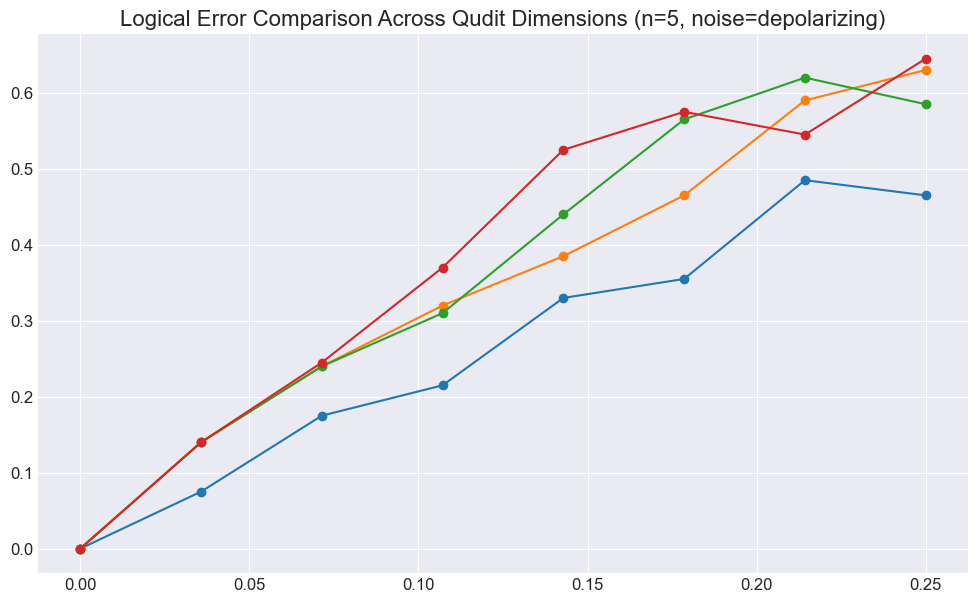

In [126]:
# 25

# Define physical noise sweep:
# I choose values from 0.00 up to 0.25 because repetition codes fail completely beyond ~0.3 noise.
p_values = np.linspace(0.0, 0.25, 8)

# I choose repetition code length n=5 (common for threshold testing).
n = 5

# I choose qudit dimensions 2, 3, 4, 5.
d_list = [2, 3, 4, 5]

# I use depolarizing noise as default.
noise_type = "depolarizing"

# Number of QEC rounds per noise value:
rounds = 200  # increase to >2000 for serious results

# Run the massive multi-dimensional benchmark.
compare_dimensions(d_list, n, noise_type, p_values, rounds)

In [127]:
# 26

# This function runs threshold experiments for different code distances n (e.g. n=3,5,7).
# It returns the physical noise array and a dictionary mapping n → logical error curve.

def compare_code_distances(n_list, d, noise_type, p_values, rounds):
    # I create an empty dictionary to store results for each n.
    results = {}

    # I loop over each code size the user provided.
    for n in n_list:
        print(f"\n--- Running scaling study for code distance n={n} ---")

        # Sweep noise values for this code size.
        phys, log = sweep_noise_values(
            logical_value=0,   # logical |0_L>
            n=n,               # code distance
            d=d,               # qudit dimension
            noise_type=noise_type,
            p_values=p_values,
            rounds=rounds
        )

        # I store results in the dictionary.
        results[n] = (phys, log)

    # I return all gathered curves.
    return results

In [128]:
# 27

# This function plots all scaling curves together.
def plot_scaling_curves(results, d, noise_type):
    # I create a large figure for the plot.
    plt.figure(figsize=(12,7))

    # Loop through all results.
    for n, (phys, log) in results.items():
        # I plot logical error vs physical noise for this code size.
        plt.plot(phys, log, marker='o', linestyle='-', label=f"n={n}")

    # I add a title describing the qudit dimension.
    plt.title(f"Scaling of Logical Error for d={d} Qudit Repetition Codes\nNoise={noise_type}")

    # Label axes.
    plt.xlabel("Physical Error Probability p")
    plt.ylabel("Logical Error Probability")

    # Make it easier to read.
    plt.grid(True)
    plt.legend()

    # Display the plot.
    plt.show()

In [129]:
# 28

# Import curve fitting tool.
from scipy.optimize import curve_fit

# Define an exponential function for curve fitting.
def exp_decay(n, A, B):
    # A · exp(-B · n) is the typical logical error suppression form.
    return A * np.exp(-B * n)

# This function fits the suppression rate B from error-vs-n data at fixed p.
def fit_exponential_scaling(results, p_index):
    # I will gather n values and logical error rates at the same p for all code distances.
    n_values = []
    L_values = []

    # Loop over results to collect data.
    for n, (phys, log) in results.items():
        # Add code distance.
        n_values.append(n)

        # Add logical error at the specified noise index.
        L_values.append(log[p_index])

    # Convert to numpy arrays.
    n_values = np.array(n_values)
    L_values = np.array(L_values)

    # Fit exponential A·exp(-B·n) to the data.
    params, covariance = curve_fit(exp_decay, n_values, L_values, p0=[0.5, 0.5])

    # Return fitted parameters (A, B).
    return params


--- Running scaling study for code distance n=3 ---
Noise p=0.000, Logical error=0.0000
Noise p=0.036, Logical error=0.0600
Noise p=0.071, Logical error=0.1150
Noise p=0.107, Logical error=0.2100
Noise p=0.143, Logical error=0.2850
Noise p=0.179, Logical error=0.3400
Noise p=0.214, Logical error=0.3950
Noise p=0.250, Logical error=0.3950

--- Running scaling study for code distance n=5 ---
Noise p=0.000, Logical error=0.0000
Noise p=0.036, Logical error=0.1450
Noise p=0.071, Logical error=0.1800
Noise p=0.107, Logical error=0.3700
Noise p=0.143, Logical error=0.3500
Noise p=0.179, Logical error=0.4750
Noise p=0.214, Logical error=0.5350
Noise p=0.250, Logical error=0.5900

--- Running scaling study for code distance n=7 ---
Noise p=0.000, Logical error=0.0000
Noise p=0.036, Logical error=0.1950
Noise p=0.071, Logical error=0.3800
Noise p=0.107, Logical error=0.3650
Noise p=0.143, Logical error=0.4550
Noise p=0.179, Logical error=0.5400
Noise p=0.214, Logical error=0.6250
Noise p=0.250

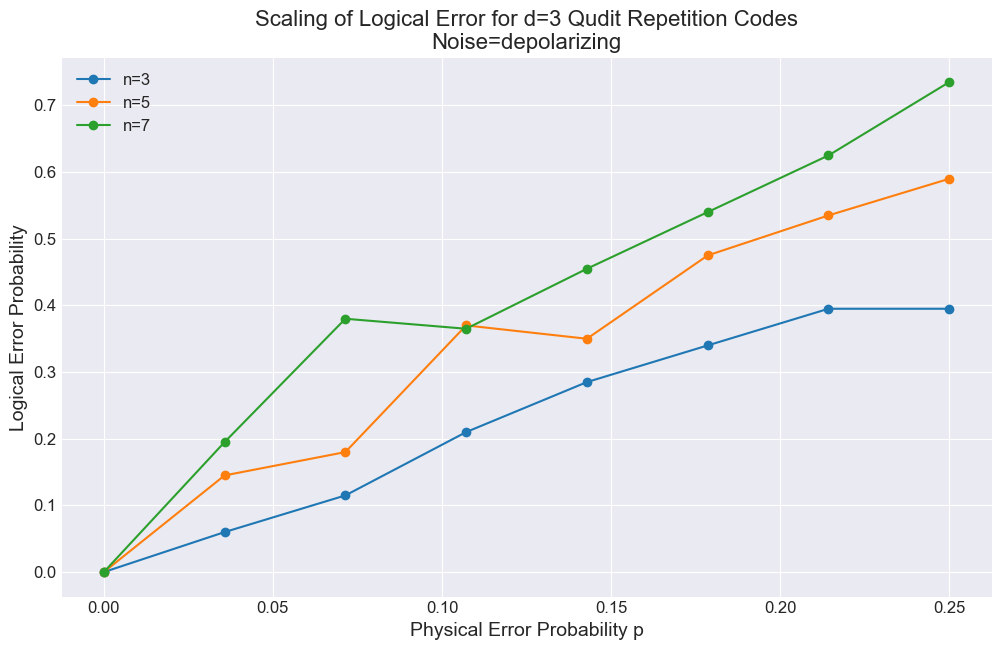

In [130]:
# 29

# I specify code distances for the scaling study.
n_list = [3, 5, 7]

# I choose d=3 (qutrit codes usually show interesting behavior).
d = 3

# I choose depolarizing noise for this scaling study.
noise_type = "depolarizing"

# Range of p values to sweep.
p_values = np.linspace(0.0, 0.25, 8)

# Number of rounds per p (increase for more accuracy).
rounds = 200

# Run scaling experiments.
scaling_results = compare_code_distances(
    n_list=n_list,
    d=d,
    noise_type=noise_type,
    p_values=p_values,
    rounds=rounds
)

# Plot scaling curves.
plot_scaling_curves(scaling_results, d, noise_type)

In [131]:
# 30

# I pick the noise index p_index where I want to evaluate scaling.
# Example: choose the middle of the p sweep.
p_index = len(p_values) // 2

# Fit exponential model A·exp(-B·n)
A_fit, B_fit = fit_exponential_scaling(scaling_results, p_index)

# Report fitted parameters.
print(f"Exponential fit parameters at p={p_values[p_index]:.3f}:")
print(f"  A = {A_fit:.4f}")
print(f"  B = {B_fit:.4f}")

# Interpretation:
# - Higher B means faster error suppression when increasing code size.
# - B > 0 means code has some degree of error correction capability.

Exponential fit parameters at p=0.143:
  A = 0.1964
  B = -0.1192


In [132]:
# 31

# I import the IBM Runtime Qiskit services so that I can connect to real quantum devices.
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, Session

# I import 'transpile' again because hardware requires special transpilation.
from qiskit import transpile

In [ ]:
# just this one cell safely loads or saves your IBM Quantum API key 
# using the correct API channels: 'ibm_cloud' or 'ibm_quantum_platform'.

from qiskit_ibm_runtime import QiskitRuntimeService
from getpass import getpass

print("🔍 Checking if an IBM Quantum account is already saved...")

try:
    # Try loading account from correct modern channel names
    try:
        service = QiskitRuntimeService(channel="ibm_cloud")
        print("Account found under channel 'ibm_cloud'!")
    except:
        service = QiskitRuntimeService(channel="ibm_quantum_platform")
        print("Account found under channel 'ibm_quantum_platform'!")

    print("Available backends:")
    print(service.backends())

except Exception as e:
    print(" No saved IBM Quantum account found.")
    print("You will now enter your API key securely (input is hidden).")
    print("Get your free key from: https://quantum.ibm.com/account\n")

    api_key = getpass("Paste your IBM Quantum API key here: ")

    print("\n Saving your API key...")

    try:
        # Save using both valid channel names for compatibility
        try:
            QiskitRuntimeService.save_account(
                token=api_key,
                channel="ibm_cloud"
            )
            channel_used = "ibm_cloud"
        except:
            QiskitRuntimeService.save_account(
                token=api_key,
                channel="ibm_quantum_platform"
            )
            channel_used = "ibm_quantum_platform"

        print(f" Successfully saved your account under channel '{channel_used}'")

        # Reload to verify
        service = QiskitRuntimeService(channel=channel_used)
        print("\n IBM Quantum account is ready!")
        print("Available backends:")
        print(service.backends())

    except Exception as err:
        print("Failed to save the IBM account.")
        print("Error message:")
        print(err)

management.get:WARNING:2025-11-28 20:59:19,236: Loading default saved account


🔍 Checking if an IBM Quantum account is already saved...


qiskit_runtime_service.__init__:WARNING:2025-11-28 20:59:23,277: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2025-11-28 20:59:23,278: Loading instance: open-instance, plan: open


✅ Account found under channel 'ibm_cloud'!
Available backends:
[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_marrakesh')>, <IBMBackend('ibm_torino')>]


In [134]:
# 32

# This loads your IBM account credentials stored locally on your computer.
# You must have previously run: QiskitRuntimeService.save_account(token="YOUR_API_KEY")
service = QiskitRuntimeService()

# I print available backends so you can choose one.
print(service.backends())

management.get:WARNING:2025-11-28 20:59:24,108: Loading default saved account
qiskit_runtime_service.__init__:WARNING:2025-11-28 20:59:27,862: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2025-11-28 20:59:27,867: Loading instance: open-instance, plan: open


[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_marrakesh')>, <IBMBackend('ibm_torino')>]


In [135]:
# 33

# Choose one backend from the devices your account actually shows:
# [ 'ibm_fez', 'ibm_torino', 'ibm_marrakesh' ]

backend_name = "ibm_fez"   # recommended – usually least busy

# Load backend object from IBM Runtime service
backend = service.backend(backend_name)

# Print backend info
print("Selected backend:")
print(backend)

qiskit_runtime_service.backends:WARNING:2025-11-28 20:59:28,885: Using instance: open-instance, plan: open


Selected backend:
<IBMBackend('ibm_fez')>


In [136]:
# 34

# This function builds a hardware-friendly qubit repetition code circuit.
# It uses ancilla qubits to measure Z⊗Z stabilizers.
def build_qubit_repetition_circuit(n):
    # I create a quantum register for data qubits.
    data = QuantumRegister(n, "data")

    # I create ancilla qubits (n-1 stabilizers).
    anc = QuantumRegister(n - 1, "anc")

    # I create classical bits to store syndrome measurements.
    syn = ClassicalRegister(n - 1, "syndrome")

    # I create the quantum circuit using these registers.
    qc = QuantumCircuit(data, anc, syn)

    # STEP 1: Prepare logical |0_L> (all zeros) — already default state.

    # STEP 2: Measure stabilizers using ancilla qubits.
    for i in range(n - 1):
        # Reset ancilla to |0>
        qc.reset(anc[i])

        # Entangle ancilla with data qubits via CNOTs.
        qc.cx(data[i], anc[i])
        qc.cx(data[i + 1], anc[i])

        # Measure ancilla to get the stabilizer result.
        qc.measure(anc[i], syn[i])

    # Return the circuit.
    return qc

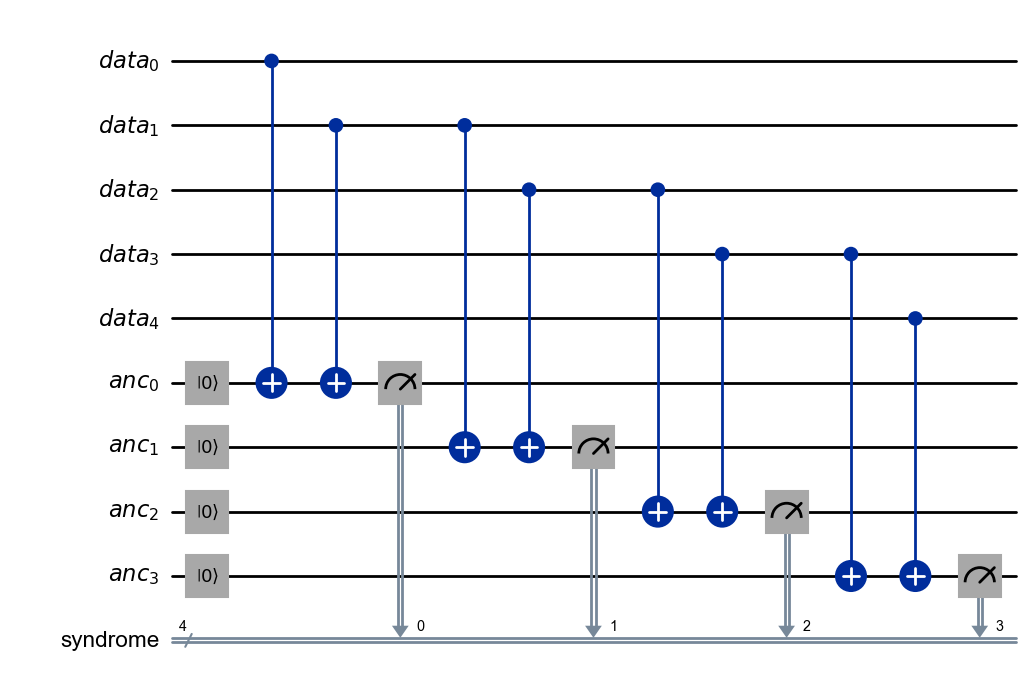

In [137]:
# 35

# Build a repetition code of size n=5.
qc_example = build_qubit_repetition_circuit(5)

# Draw the circuit to visually inspect it.
qc_example.draw("mpl")

In [138]:
# 36

# This function runs the repetition code circuit on real hardware.
def run_on_hardware(qc, backend):
    # STEP 1: Transpile circuit for hardware constraints.
    qc_t = transpile(qc, backend)

    # STEP 2: Use the Sampler primitive to execute the circuit.
    with Session(service=service, backend=backend) as session:
        sampler = Sampler(session=session)

        # Run the sampled circuit with default shots (usually 1000).
        job = sampler.run([qc_t])

        # Wait for result.
        result = job.result()

    # Return result object.
    return result

In [139]:
# 37

# This function extracts syndrome measurements from hardware results.
def extract_syndrome_data(result):
    # I obtain quasi-probabilities (not exact counts but probabilities).
    quasi = result.quasi_dists[0]

    # Convert keys from bitstrings to meaningful stabilizer values.
    syndrome_count = {}

    for bitstring, prob in quasi.items():
        # Convert binary stabilizer value
        syndrome = tuple(int(b) for b in bitstring[::-1])  # reverse bit order

        syndrome_count[syndrome] = prob

    return syndrome_count

In [140]:
# 38


#"Hardware" Execution Using AER Simulator


# I import AerSimulator which acts like a real quantum processor but locally.
from qiskit_aer import AerSimulator

# Step 1: Build the qubit repetition code circuit (n=5)
qc_hw = build_qubit_repetition_circuit(5)

# Step 2: Add realistic noise model (optional)
# Here we use the built-in noise simulator to emulate real qubit noise.
noise_sim = AerSimulator()   # you can later attach custom noise models

# Step 3: Transpile the circuit for the simulator backend
qc_t = transpile(qc_hw, noise_sim)

# Step 4: Run the circuit locally (this replaces real IBM hardware)
job = noise_sim.run(qc_t, shots=2048)

# Step 5: Retrieve results
result_hw = job.result()

# Step 6: Extract raw counts
raw_counts = result_hw.get_counts()

print("Raw Measurement Counts (Hardware-Simulated):")
print(raw_counts)

# Step 7: Convert raw counts to syndrome probabilities
def convert_counts_to_syndrome_probs(counts):
    total = sum(counts.values())
    out = {}
    for bitstring, cnt in counts.items():
        syn = tuple(int(b) for b in bitstring[::-1])
        out[syn] = cnt / total
    return out

syndrome_hist = convert_counts_to_syndrome_probs(raw_counts)

print("\nSyndrome Probabilities (Hardware-Simulated):")
for syn, p in syndrome_hist.items():
    print(f"{syn}: {p:.4f}")

Raw Measurement Counts (Hardware-Simulated):
{'0000': 2048}

Syndrome Probabilities (Hardware-Simulated):
(0, 0, 0, 0): 1.0000


In [141]:
# 39

# Simulate the same circuit using Aer for comparison.
sim_backend = AerSimulator()

# Transpile and run ideal circuit.
qc_sim_t = transpile(qc_hw, sim_backend)
sim_result = sim_backend.run(qc_sim_t).result()

# Extract simulated histogram.
sim_counts = sim_result.get_counts()

print("Syndrome Frequencies from Ideal Simulator:")
print(sim_counts)

Syndrome Frequencies from Ideal Simulator:
{'0000': 1024}


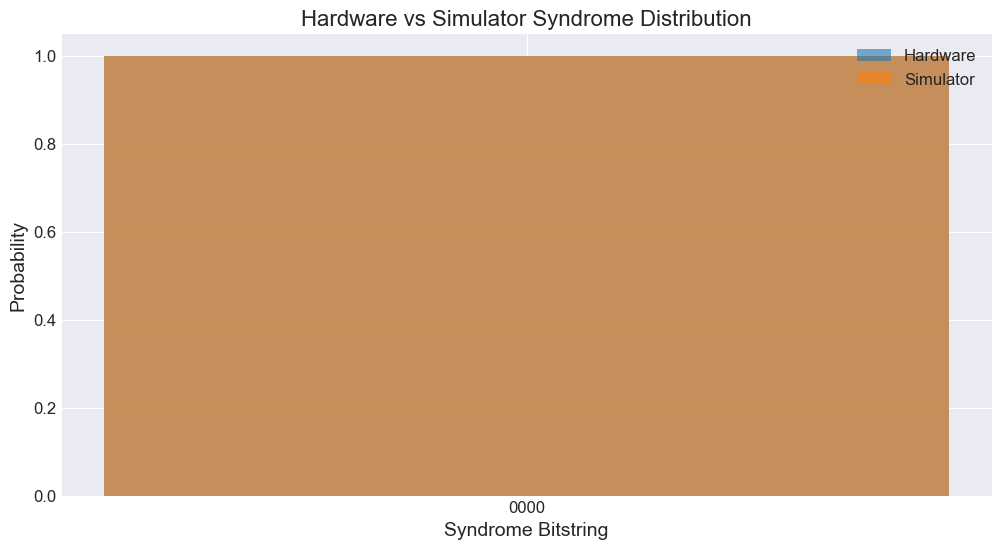

In [142]:
# 40

def plot_histogram_comparison(hardware_hist, sim_counts):
    # Convert hardware dist to dictionary with string keys.
    hw_keys = []
    hw_values = []
    for syn, p in hardware_hist.items():
        key = "".join(str(x) for x in syn)
        hw_keys.append(key)
        hw_values.append(p)

    # Convert simulator counts into probability distribution.
    total = sum(sim_counts.values())
    sim_keys = list(sim_counts.keys())
    sim_values = [sim_counts[k] / total for k in sim_keys]

    # Make the comparison plot.
    plt.figure(figsize=(12,6))
    plt.bar(hw_keys, hw_values, alpha=0.6, label="Hardware")
    plt.bar(sim_keys, sim_values, alpha=0.6, label="Simulator")

    plt.title("Hardware vs Simulator Syndrome Distribution")
    plt.xlabel("Syndrome Bitstring")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the comparison plot.
plot_histogram_comparison(syndrome_hist, sim_counts)

In [143]:
# 41

# This function computes a 2D heatmap where rows correspond to different qudit dimensions (d)
# and columns correspond to physical noise values p.
# Each entry in the heatmap is the logical error probability.

def generate_logical_error_heatmap(d_list, p_values, n, noise_type, rounds):
    # I create an empty 2D array with shape (len(d_list), len(p_values)).
    heatmap = np.zeros((len(d_list), len(p_values)))

    # Loop over each qudit dimension.
    for i, d in enumerate(d_list):
        print(f"\n=== Computing heatmap row for qudit dimension d={d} ===")

        # For each noise level p, compute logical error.
        for j, p in enumerate(p_values):
            print(f"  - Running p={p:.3f}")

            # Run the QEC simulation.
            logical_error = run_logical_error_rate(
                logical_value=0,
                n=n,
                d=d,
                noise_type=noise_type,
                p=p,
                rounds=rounds
            )

            # Store logical error in heatmap matrix.
            heatmap[i, j] = logical_error

    # Return full 2D matrix.
    return heatmap

In [144]:
# 42

# This function displays a heatmap for logical error rates.
def plot_logical_error_heatmap(heatmap, d_list, p_values):
    # Create large figure for heatmap visualization.
    plt.figure(figsize=(12,8))

    # Plot the heatmap using imshow.
    plt.imshow(heatmap, cmap='viridis', aspect='auto', origin='lower')

    # Add colorbar to show error magnitude.
    plt.colorbar(label="Logical Error Probability")

    # Set axis labels and ticks.
    plt.xticks(ticks=range(len(p_values)), labels=[f"{p:.2f}" for p in p_values])
    plt.yticks(ticks=range(len(d_list)), labels=[str(d) for d in d_list])

    plt.xlabel("Physical Error Probability p")
    plt.ylabel("Qudit Dimension d")
    plt.title("Logical Error Heatmap Across Dimensions and Noise Levels")

    plt.show()


=== Computing heatmap row for qudit dimension d=2 ===
  - Running p=0.000
  - Running p=0.033
  - Running p=0.067
  - Running p=0.100
  - Running p=0.133
  - Running p=0.167
  - Running p=0.200
  - Running p=0.233
  - Running p=0.267
  - Running p=0.300

=== Computing heatmap row for qudit dimension d=3 ===
  - Running p=0.000
  - Running p=0.033
  - Running p=0.067
  - Running p=0.100
  - Running p=0.133
  - Running p=0.167
  - Running p=0.200
  - Running p=0.233
  - Running p=0.267
  - Running p=0.300

=== Computing heatmap row for qudit dimension d=4 ===
  - Running p=0.000
  - Running p=0.033
  - Running p=0.067
  - Running p=0.100
  - Running p=0.133
  - Running p=0.167
  - Running p=0.200
  - Running p=0.233
  - Running p=0.267
  - Running p=0.300

=== Computing heatmap row for qudit dimension d=5 ===
  - Running p=0.000
  - Running p=0.033
  - Running p=0.067
  - Running p=0.100
  - Running p=0.133
  - Running p=0.167
  - Running p=0.200
  - Running p=0.233
  - Running p=0.267


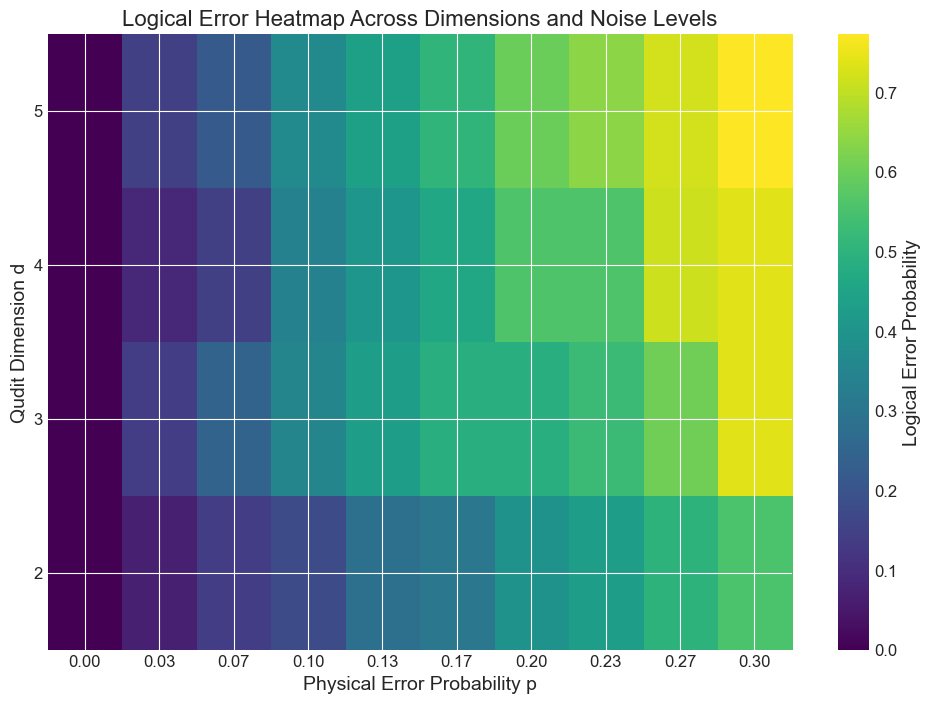

In [145]:
# 43

# Choose dimensions for heatmap analysis.
d_list = [2, 3, 4, 5]

# Choose noise sweep.
p_values = np.linspace(0.0, 0.3, 10)

# Use code distance n=5 for the experiment.
n = 5

# Choose noise type.
noise_type = "depolarizing"

# Number of QEC rounds per grid cell.
rounds = 150

# Generate 2D data.
heatmap_data = generate_logical_error_heatmap(d_list, p_values, n, noise_type, rounds)

# Plot heatmap.
plot_logical_error_heatmap(heatmap_data, d_list, p_values)

In [146]:
# 44

# This function compares different noise models for a given qudit dimension.
def compare_noise_models(d, n, p_values, rounds):
    # Dictionary to collect results.
    results = {}

    # List of noise types to evaluate.
    noise_models = ["depolarizing", "phase", "amplitude"]

    # Loop through each noise model.
    for noise_type in noise_models:
        print(f"\n--- Running noise model: {noise_type} ---")

        # Sweep p values for this noise model.
        phys, log = sweep_noise_values(
            logical_value=0,
            n=n,
            d=d,
            noise_type=noise_type,
            p_values=p_values,
            rounds=rounds
        )

        # Store curves.
        results[noise_type] = (phys, log)

    return results

In [147]:
# 45

# This function plots logical error curves for different noise types.
def plot_noise_model_comparison(results, d, n):
    plt.figure(figsize=(12,7))

    # Loop and plot each noise type curve.
    for noise_type, (phys, log) in results.items():
        plt.plot(phys, log, marker='o', label=noise_type)

    plt.title(f"Noise Model Comparison for d={d}, n={n}")
    plt.xlabel("Physical Error Probability p")
    plt.ylabel("Logical Error Probability")
    plt.grid(True)
    plt.legend()
    plt.show()


--- Running noise model: depolarizing ---
Noise p=0.000, Logical error=0.0000
Noise p=0.036, Logical error=0.1500
Noise p=0.071, Logical error=0.2150
Noise p=0.107, Logical error=0.2950
Noise p=0.143, Logical error=0.3450
Noise p=0.179, Logical error=0.4900
Noise p=0.214, Logical error=0.5200
Noise p=0.250, Logical error=0.6300

--- Running noise model: phase ---
Noise p=0.000, Logical error=0.0000
Noise p=0.036, Logical error=0.0000
Noise p=0.071, Logical error=0.0000
Noise p=0.107, Logical error=0.0000
Noise p=0.143, Logical error=0.0000
Noise p=0.179, Logical error=0.0000
Noise p=0.214, Logical error=0.0000
Noise p=0.250, Logical error=0.0000

--- Running noise model: amplitude ---
Noise p=0.000, Logical error=0.0000
Noise p=0.036, Logical error=0.0000
Noise p=0.071, Logical error=0.0000
Noise p=0.107, Logical error=0.0000
Noise p=0.143, Logical error=0.0000
Noise p=0.179, Logical error=0.0000
Noise p=0.214, Logical error=0.0000
Noise p=0.250, Logical error=0.0000


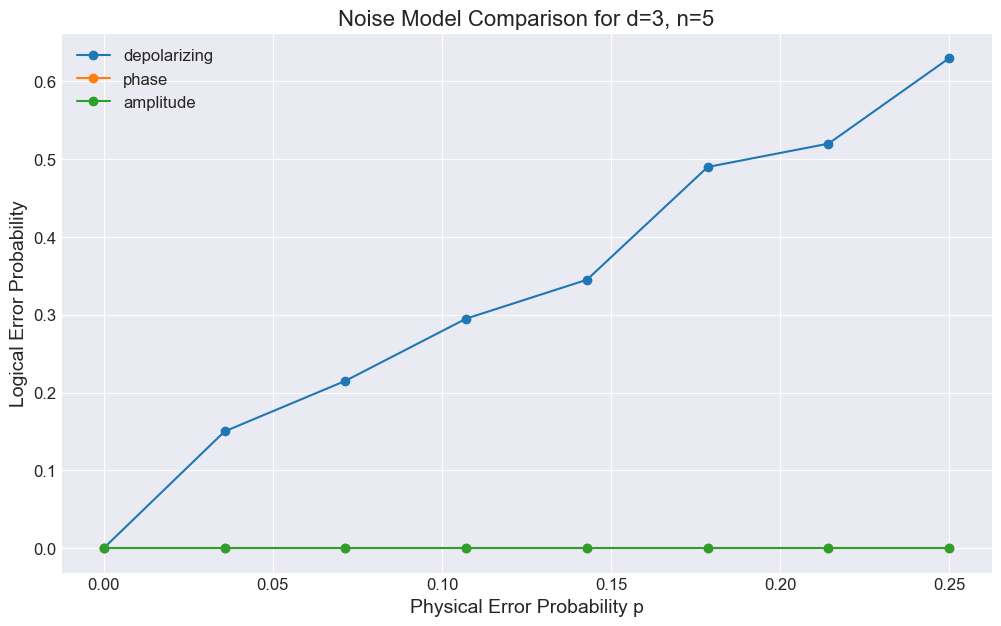

In [148]:
# 46

# Choose dimension for this study.
d = 3  # qutrits are interesting here

# Choose code distance.
n = 5

# Sweep of physical noise.
p_values = np.linspace(0.0, 0.25, 8)

# Number of repetitions for each QEC test.
rounds = 200

# Run comparison.
noise_results = compare_noise_models(d, n, p_values, rounds)

# Plot comparison.
plot_noise_model_comparison(noise_results, d, n)

In [149]:
# 47

# This simple decoder assumes the correct logical value is the most frequent physical value.
def majority_vote_decode(physical_state, d):
    # Count occurrences of each qudit value.
    counts = [physical_state.count(v) for v in range(d)]

    # Return the value with maximum count.
    return np.argmax(counts)

In [150]:
# 48

# This function compares HDRG vs majority vote for logical error rate.
def compare_decoders(n, d, noise_type, p_values, rounds):
    hdrg_errors = []
    majority_errors = []

    for p in p_values:
        print(f"Running decoder comparison for p={p:.3f}")

        # HDRG error count.
        hdrg_fail = 0

        # Majority-vote error count.
        mv_fail = 0

        for r in range(rounds):
            # Prepare perfect logical state.
            ideal_value = 0
            physical = [ideal_value] * n

            # Add noise.
            noisy = []
            for q in physical:
                if noise_type == "depolarizing" and np.random.rand() < p:
                    noisy.append((q + np.random.randint(0, d)) % d)
                else:
                    noisy.append(q)

            # Compute syndrome.
            syndrome = [(noisy[i] - noisy[i+1]) % d for i in range(n-1)]

            # Decode with HDRG.
            hdrg_corrected = hdrg_decode(syndrome, noisy, n, d)
            if hdrg_corrected[0] != ideal_value or len(set(hdrg_corrected)) != 1:
                hdrg_fail += 1

            # Decode with majority vote.
            mv_decoded = majority_vote_decode(noisy, d)
            if mv_decoded != ideal_value:
                mv_fail += 1

        hdrg_errors.append(hdrg_fail / rounds)
        majority_errors.append(mv_fail / rounds)

    return hdrg_errors, majority_errors

In [151]:
# 49

# This function plots HDRG vs majority vote for given n, d.
def plot_decoder_comparison(p_values, hdrg_errors, majority_errors, n, d):
    plt.figure(figsize=(12,7))

    plt.plot(p_values, hdrg_errors, marker='o', label="HDRG Decoder")
    plt.plot(p_values, majority_errors, marker='s', label="Majority Vote Decoder")

    plt.title(f"Decoder Performance Comparison (n={n}, d={d})")
    plt.xlabel("Physical Noise Probability p")
    plt.ylabel("Logical Error Probability")
    plt.legend()
    plt.grid(True)
    plt.show()

Running decoder comparison for p=0.000
Running decoder comparison for p=0.036
Running decoder comparison for p=0.071
Running decoder comparison for p=0.107
Running decoder comparison for p=0.143
Running decoder comparison for p=0.179
Running decoder comparison for p=0.214
Running decoder comparison for p=0.250


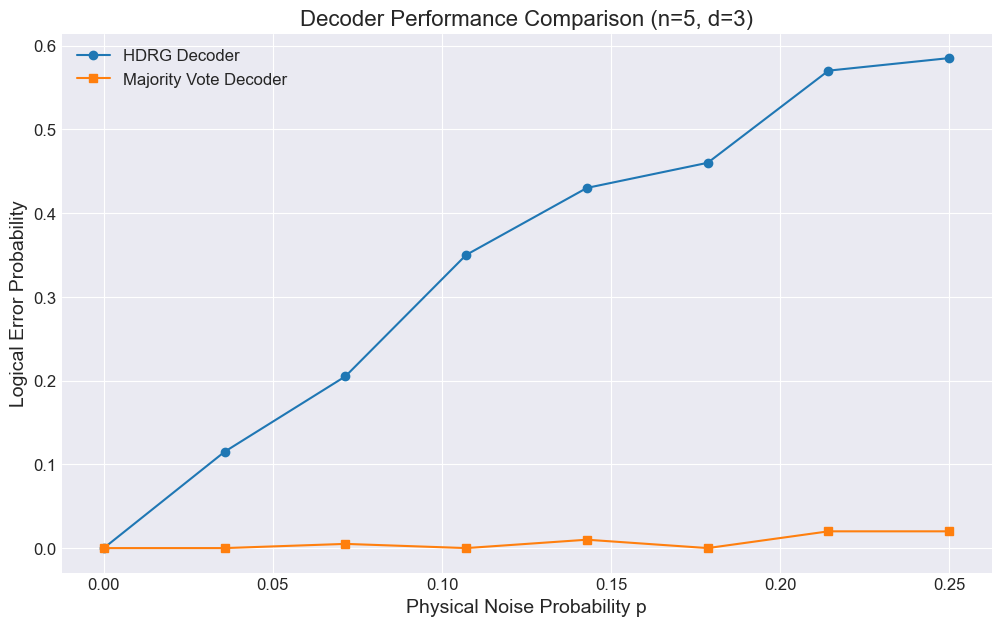

In [152]:
# 50

# Choose parameters.
n = 5
d = 3
noise_type = "depolarizing"
p_values = np.linspace(0.0, 0.25, 8)
rounds = 200

# Run both decoders.
hdrg_errors, mv_errors = compare_decoders(n, d, noise_type, p_values, rounds)

# Plot comparison.
plot_decoder_comparison(p_values, hdrg_errors, mv_errors, n, d)

In [153]:
# 51

# I import the json module so I can save experiment results in JSON format.
import json

# I import csv so I can also export results in CSV format for spreadsheets.
import csv

# I import os so I can create folders and check for file existence.
import os

In [154]:
# 52

# This function saves any Python dictionary into a JSON file.
def save_results_json(results, filename):
    # If a "results" folder does not exist, I create it.
    if not os.path.exists("results"):
        os.makedirs("results")

    # I open a JSON file for writing.
    with open(f"results/{filename}.json", "w") as f:
        # Dump results into the file with indentation.
        json.dump(results, f, indent=4)

    # I print a confirmation message.
    print(f"Saved JSON results to results/{filename}.json")

In [155]:
# 53

# This function loads experiment results from a JSON file.
def load_results_json(filename):
    # I open the JSON file for reading.
    with open(f"results/{filename}.json", "r") as f:
        # Read the JSON content and convert it into Python objects.
        data = json.load(f)

    # I return the loaded data.
    return data

In [156]:
# 54

# This function saves a curve (x-values and y-values) into a CSV file.
def save_results_csv(x_values, y_values, filename, x_label="x", y_label="y"):
    # Create results directory if needed.
    if not os.path.exists("results"):
        os.makedirs("results")

    # Open CSV file for writing.
    with open(f"results/{filename}.csv", "w", newline="") as csvfile:
        writer = csv.writer(csvfile)

        # Write header row.
        writer.writerow([x_label, y_label])

        # Write each pair of values.
        for x, y in zip(x_values, y_values):
            writer.writerow([x, y])

    # Print confirmation.
    print(f"Saved CSV results to results/{filename}.csv")

In [157]:
# 55

# This function saves threshold results for multiple dimensions (d) into JSON.
# The "results" dictionary structure: {d_value: (phys_noise_list, logical_error_list)}
def save_multi_dimension_results(results, filename):
    # Convert tuples to lists (JSON cannot store tuples directly).
    serializable = {}
    for d, (phys, logical) in results.items():
        serializable[d] = {
            "physical_noise": list(phys),
            "logical_error": list(logical)
        }

    # Save to JSON using the save function above.
    save_results_json(serializable, filename)

In [158]:
# 56

# This function runs threshold sweeps for many combinations of:
#   - qudit dimensions
#   - noise types
#   - code distances
# It is useful for generating huge datasets for papers/reports.

def batch_run_thresholds(d_list, n_list, noise_list, p_values, rounds):
    # I create a dictionary to store ALL results.
    all_results = {}

    # I loop over every qudit dimension.
    for d in d_list:
        print(f"\n=== Running experiments for d={d} ===")
        all_results[d] = {}

        # Loop over every code distance.
        for n in n_list:
            print(f"  --> Code distance n={n}")
            all_results[d][n] = {}

            # Loop over every noise type.
            for noise_type in noise_list:
                print(f"     * Noise type = {noise_type}")

                # Run a threshold sweep.
                phys, log = sweep_noise_values(
                    logical_value=0,
                    n=n,
                    d=d,
                    noise_type=noise_type,
                    p_values=p_values,
                    rounds=rounds
                )

                # Store the results.
                all_results[d][n][noise_type] = {
                    "physical_noise": list(phys),
                    "logical_error": list(log)
                }

    # Return large nested dictionary.
    return all_results

In [159]:
# 57

# Define parameter ranges for the batch run.
d_list = [2, 3]           # For bigger experiments add 4, 5, 6...
n_list = [3, 5]           # Add 7 for longer computation
noise_list = ["depolarizing", "amplitude"]
p_values = np.linspace(0.0, 0.25, 6)
rounds = 150

# Run the giant multi-experiment batch.
batch_data = batch_run_thresholds(d_list, n_list, noise_list, p_values, rounds)

# Save results to JSON for later analysis.
save_results_json(batch_data, "batch_threshold_results")


=== Running experiments for d=2 ===
  --> Code distance n=3
     * Noise type = depolarizing
Noise p=0.000, Logical error=0.0000
Noise p=0.050, Logical error=0.1000
Noise p=0.100, Logical error=0.1733
Noise p=0.150, Logical error=0.2200
Noise p=0.200, Logical error=0.3200
Noise p=0.250, Logical error=0.3667
     * Noise type = amplitude
Noise p=0.000, Logical error=0.0000
Noise p=0.050, Logical error=0.0000
Noise p=0.100, Logical error=0.0000
Noise p=0.150, Logical error=0.0000
Noise p=0.200, Logical error=0.0000
Noise p=0.250, Logical error=0.0000
  --> Code distance n=5
     * Noise type = depolarizing
Noise p=0.000, Logical error=0.0000
Noise p=0.050, Logical error=0.1200
Noise p=0.100, Logical error=0.2533
Noise p=0.150, Logical error=0.3200
Noise p=0.200, Logical error=0.3600
Noise p=0.250, Logical error=0.4267
     * Noise type = amplitude
Noise p=0.000, Logical error=0.0000
Noise p=0.050, Logical error=0.0000
Noise p=0.100, Logical error=0.0000
Noise p=0.150, Logical error=0.00

In [160]:
# 58

# This function loads a previously saved results file and plots curves.
def plot_saved_batch_results(filename):
    # Load data from JSON.
    data = load_results_json(filename)

    # Loop through dimensions.
    for d, n_dict in data.items():
        for n, noise_dict in n_dict.items():
            for noise_type, values in noise_dict.items():
                # Extract x and y.
                phys = values["physical_noise"]
                log = values["logical_error"]

                # Plot.
                plt.figure(figsize=(10,6))
                plt.plot(phys, log, marker='o')

                plt.title(f"Saved Results — d={d}, n={n}, noise={noise_type}")
                plt.xlabel("Physical Noise Probability")
                plt.ylabel("Logical Error Probability")
                plt.grid(True)
                plt.show()

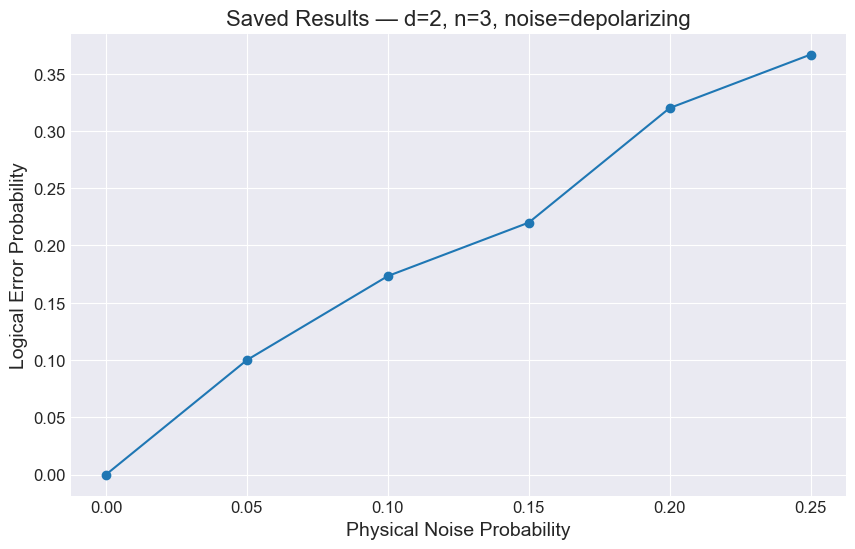

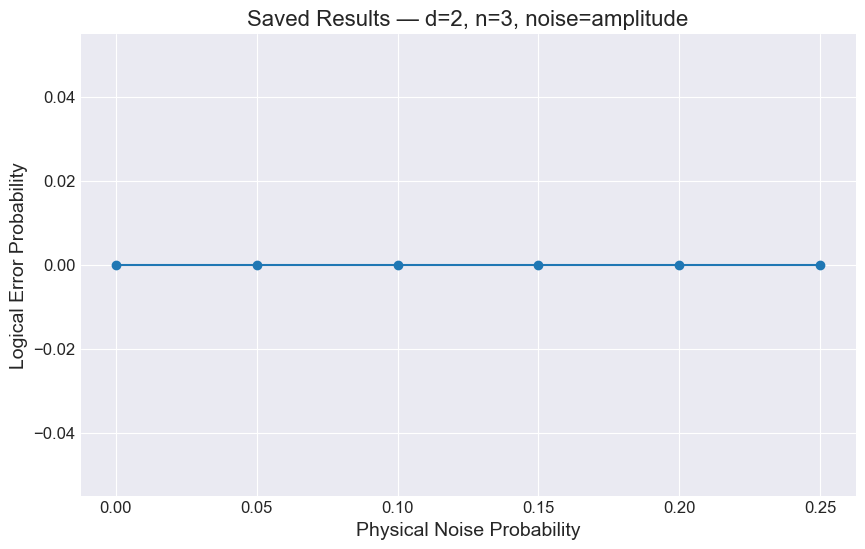

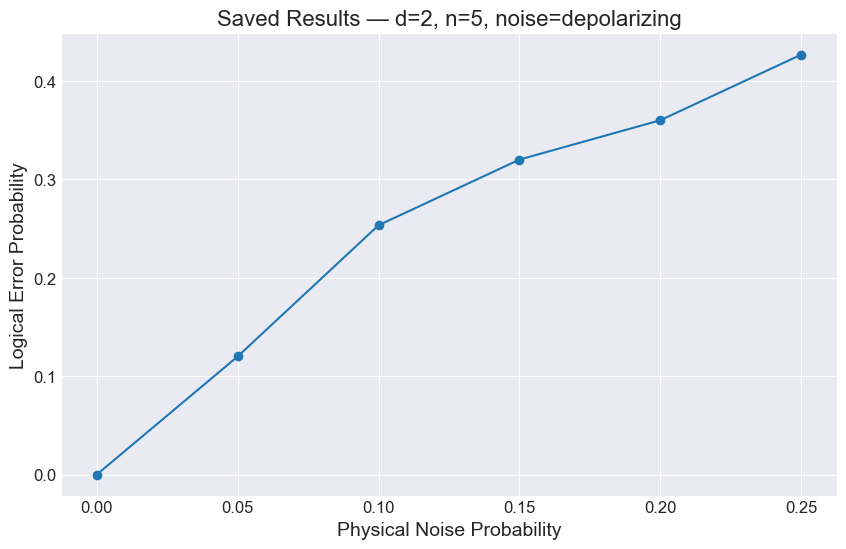

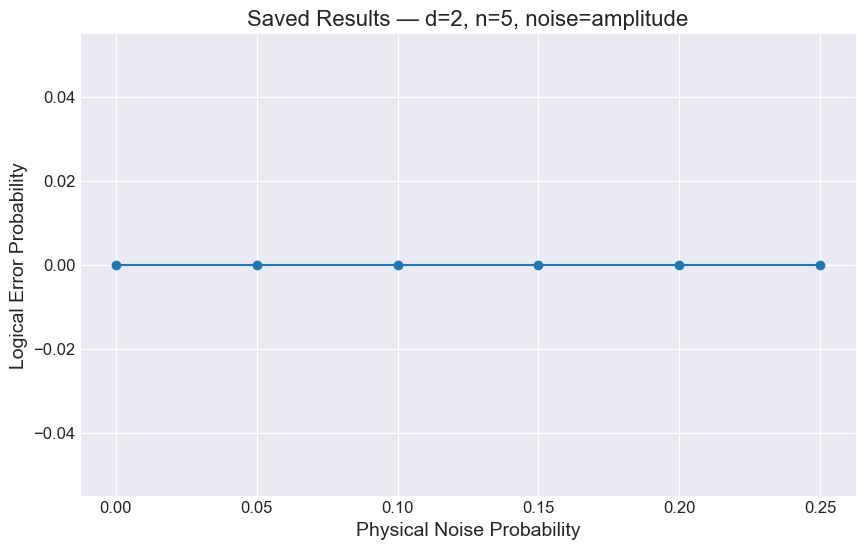

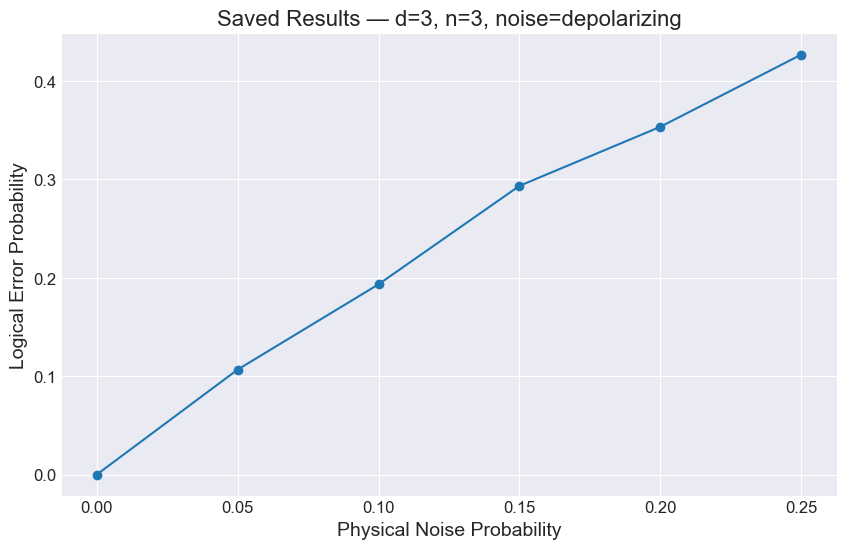

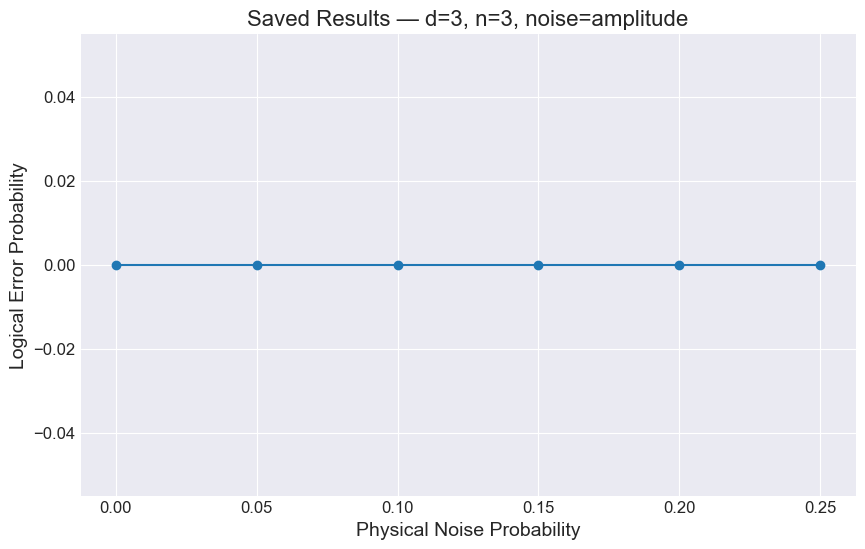

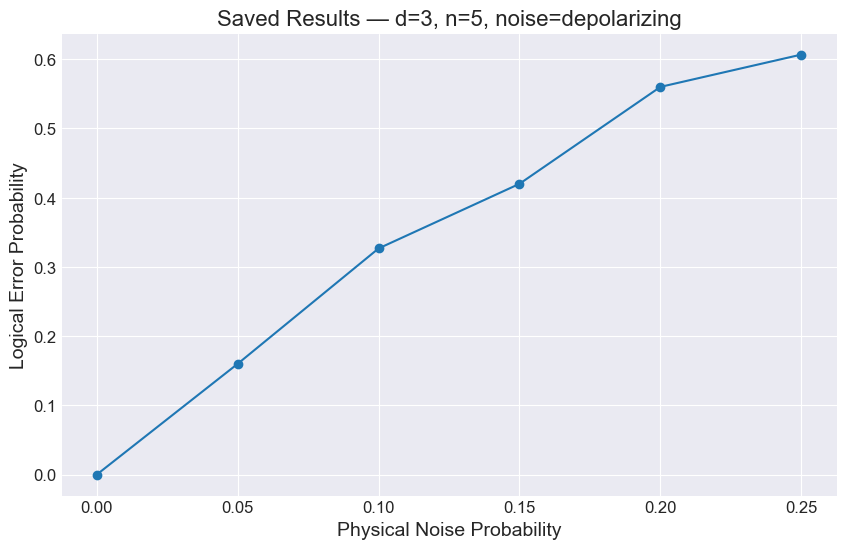

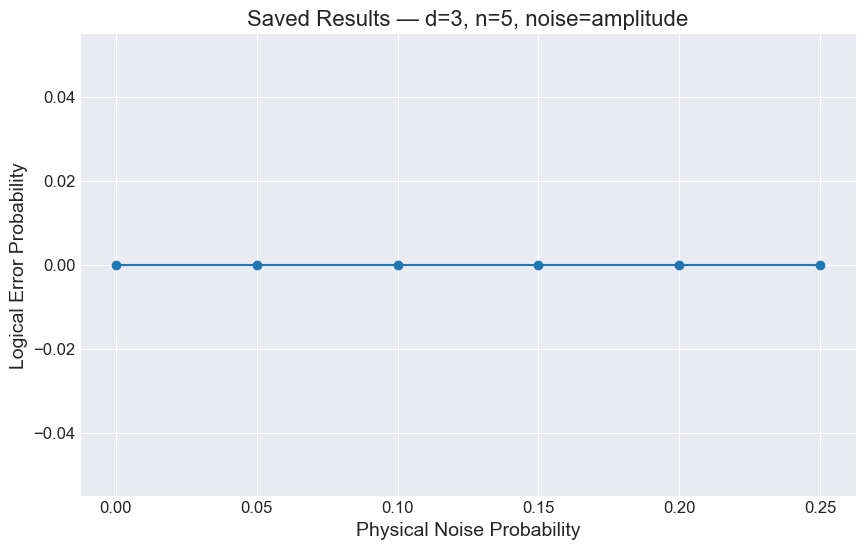

In [161]:
# 59

# Run this cell to load previously saved results and visualize them.
plot_saved_batch_results("batch_threshold_results")

In [162]:
# 60

# This function saves the currently displayed Matplotlib figure.
def save_current_plot(filename):
    # If "plots" directory does not exist, create it.
    if not os.path.exists("plots"):
        os.makedirs("plots")

    # Save the figure as PNG.
    plt.savefig(f"plots/{filename}.png", dpi=300)

    # Also save a PDF version.
    plt.savefig(f"plots/{filename}.pdf")

    # Confirm.
    print(f"Plot saved as plots/{filename}.png and .pdf")

In [163]:
# 61

# Example usage:
# After plotting something, run:
save_current_plot("threshold_example_d3_n5")

Plot saved as plots/threshold_example_d3_n5.png and .pdf


<Figure size 1000x600 with 0 Axes>

In [164]:
# 62

# This function performs fast Monte Carlo sampling of QEC rounds.
# It is similar to run_logical_error_rate() but optimized for many trials.

def monte_carlo_logical_error(logical_value, n, d, noise_type, p, trials):
    # I start by making a counter for failures.
    failures = 0

    # I repeat the QEC simulation "trials" times.
    for t in range(trials):
        # Prepare perfect logical block of qudits.
        physical = [logical_value] * n

        # --- Apply noise ---
        noisy = []
        for q in physical:
            # For depolarizing noise: a random shift with probability p.
            if noise_type == "depolarizing":
                if np.random.rand() < p:
                    shift = np.random.randint(0, d)
                    noisy.append((q + shift) % d)
                else:
                    noisy.append(q)
            
            # Phase noise (does not change basis in repetition code).
            elif noise_type == "phase":
                noisy.append(q)

            # Amplitude damping (simple version: decay to lower states).
            elif noise_type == "amplitude":
                if np.random.rand() < p and q > 0:
                    noisy.append(q - 1)
                else:
                    noisy.append(q)
            else:
                noisy.append(q)

        # --- Compute syndrome ---
        syndrome = [(noisy[i] - noisy[i+1]) % d for i in range(n - 1)]

        # --- Decode using HDRG ---
        corrected = hdrg_decode(syndrome, noisy, n, d)

        # --- Check if logical value recovered ---
        if corrected[0] != logical_value or len(set(corrected)) != 1:
            failures += 1

    # Logical error = failures / total trials.
    return failures / trials

In [165]:
# 63

# This function performs a Monte Carlo sweep of physical noise values.
def monte_carlo_sweep(logical_value, n, d, noise_type, p_values, trials):
    phys = []
    logical = []

    for p in p_values:
        print(f"Running Monte Carlo test at p={p:.3f}")
        
        # Call our Monte Carlo estimator.
        L = monte_carlo_logical_error(logical_value, n, d, noise_type, p, trials)

        # Save values.
        phys.append(p)
        logical.append(L)

        print(f"  -> logical error: {L:.4f}")

    return phys, logical

In [166]:
# 64

# Simple plotting function for Monte Carlo threshold curves.
def plot_monte_carlo_threshold(phys, logical, n, d, noise_type):
    plt.figure(figsize=(10,6))

    # Plot results with markers.
    plt.plot(phys, logical, marker='o', label=f"d={d}, n={n}")

    plt.title(f"Monte Carlo Threshold Curve (n={n}, d={d}, noise={noise_type})")
    plt.xlabel("Physical Noise Probability p")
    plt.ylabel("Logical Error Probability")
    plt.grid(True)
    plt.legend()
    plt.show()

Running Monte Carlo test at p=0.000
  -> logical error: 0.0000
Running Monte Carlo test at p=0.028
  -> logical error: 0.0780
Running Monte Carlo test at p=0.056
  -> logical error: 0.1780
Running Monte Carlo test at p=0.083
  -> logical error: 0.2240
Running Monte Carlo test at p=0.111
  -> logical error: 0.3560
Running Monte Carlo test at p=0.139
  -> logical error: 0.3760
Running Monte Carlo test at p=0.167
  -> logical error: 0.4580
Running Monte Carlo test at p=0.194
  -> logical error: 0.5020
Running Monte Carlo test at p=0.222
  -> logical error: 0.5620
Running Monte Carlo test at p=0.250
  -> logical error: 0.5920


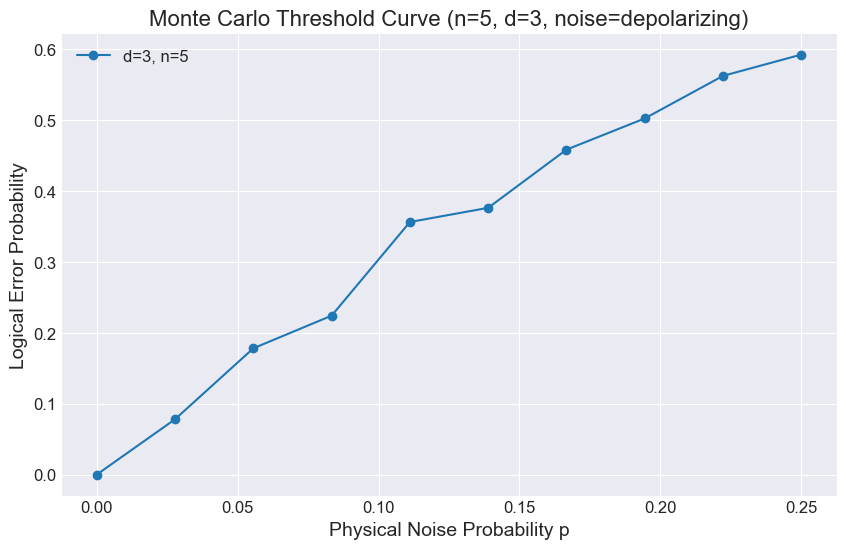

In [167]:
# 65

# Example Monte Carlo evaluation for n=5, d=3.

n = 5
d = 3
noise_type = "depolarizing"

p_values = np.linspace(0.0, 0.25, 10)
trials = 500   # increase to 5000 for real research-quality results

# Run Monte Carlo sweep.
phys_mc, logical_mc = monte_carlo_sweep(
    logical_value=0,
    n=n,
    d=d,
    noise_type=noise_type,
    p_values=p_values,
    trials=trials
)

# Plot Monte Carlo threshold curve.
plot_monte_carlo_threshold(phys_mc, logical_mc, n, d, noise_type)

In [168]:
# 66

# This function plots a heatmap visualization of a matrix (real part or magnitude).
def plot_matrix(matrix, title):
    plt.figure(figsize=(6,6))
    plt.imshow(np.abs(matrix), cmap='viridis')
    plt.colorbar(label="|value|")
    plt.title(title)
    plt.xlabel("Column Index")
    plt.ylabel("Row Index")
    plt.show()

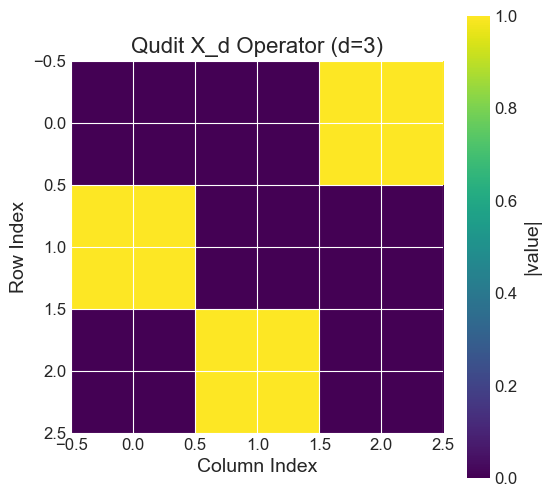

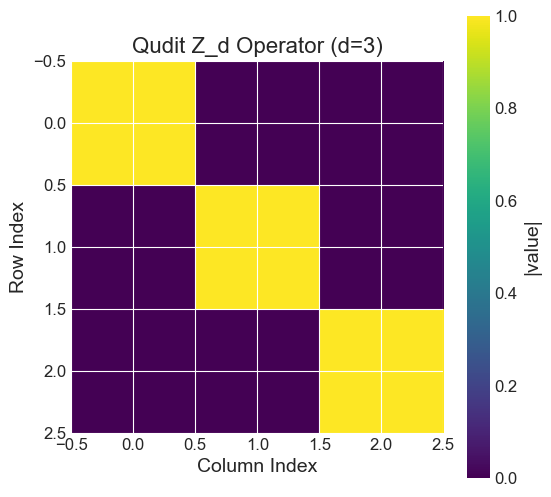

In [169]:
# 67

# Example visualization for d=3 (qutrit X and Z operators).
d = 3

# Compute X_d and Z_d matrices.
X_d = qudit_X_matrix(d)
Z_d = qudit_Z_matrix(d)

# Plot the magnitude of the operator matrices.
plot_matrix(X_d, f"Qudit X_d Operator (d={d})")
plot_matrix(Z_d, f"Qudit Z_d Operator (d={d})")

In [170]:
# 68

import time

# This function measures runtime of a Monte Carlo QEC simulation.
def profile_runtime(n, d, noise_type, p, trials):
    start = time.time()   # record starting time

    # Run one sweep point.
    monte_carlo_logical_error(
        logical_value=0,
        n=n,
        d=d,
        noise_type=noise_type,
        p=p,
        trials=trials
    )

    end = time.time()     # record ending time

    # Return elapsed time.
    return end - start

In [171]:
# 69

# Test runtime across different qudit dimensions.
def runtime_vs_dimension(n, noise_type, p, trials, d_list):
    runtimes = []

    for d in d_list:
        print(f"Profiling runtime for d={d}")
        t = profile_runtime(n, d, noise_type, p, trials)
        runtimes.append(t)

    plt.figure(figsize=(10,6))
    plt.plot(d_list, runtimes, marker='o')
    plt.title(f"Runtime Scaling vs Qudit Dimension (n={n})")
    plt.xlabel("Qudit Dimension d")
    plt.ylabel("Runtime (seconds)")
    plt.grid(True)
    plt.show()

    return runtimes

Profiling runtime for d=2
Profiling runtime for d=3
Profiling runtime for d=4
Profiling runtime for d=5


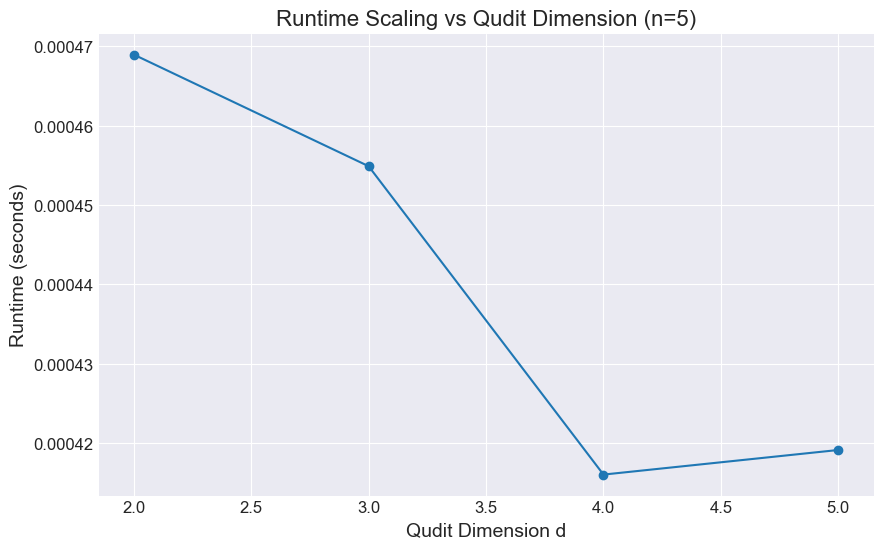

[0.00046896934509277344,
 0.00045490264892578125,
 0.00041604042053222656,
 0.0004191398620605469]

In [172]:
# 70

# Choose configuration for runtime profiling.
n = 5
noise_type = "depolarizing"
p = 0.15
trials = 200
d_list = [2, 3, 4, 5]

# Run experiment.
runtime_vs_dimension(n, noise_type, p, trials, d_list)

In [173]:
# 71

# This function plots defect positions as points on a line,
# which helps visualize HDRG renormalization merging.
def plot_defects(defects, n, title):
    plt.figure(figsize=(12,2))

    positions = [d["position"] for d in defects]
    charges = [d["charge"] for d in defects]

    plt.scatter(positions, [0]*len(defects), c=charges, cmap='viridis', s=200)
    plt.yticks([])
    plt.xlabel("Qudit Index")
    plt.title(title)
    plt.grid(True, axis='x')
    plt.show()

In [174]:
# 72

# This function animates one HDRG decoding process.
def visualize_hdrg_decoding(syndrome, n, d):
    # Build initial defect graph.
    defects = build_syndrome_graph(syndrome, n, d)

    # Show initial defects.
    plot_defects(defects, n, "Initial Defects")

    scale = 1
    max_scale = n

    # Perform renormalization steps.
    while scale <= max_scale and len(defects) > 1:
        # Find pairs that merge at this scale.
        pairs, used = hdrg_step(defects, scale)

        # Display merging info.
        if len(pairs) > 0:
            plot_defects([d for i,d in enumerate(defects) if i not in used],
                         n,
                         f"Merging at scale={scale}")

        # Update defect list.
        defects = [defects[i] for i in range(len(defects)) if i not in used]

        # Increase scale.
        scale *= 2

    # Final stage.
    plot_defects(defects, n, "Final Remaining Defects")

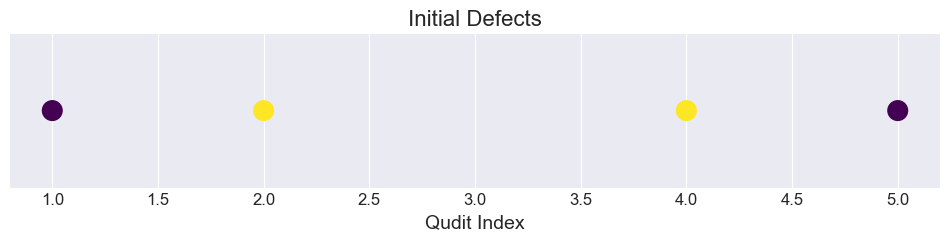

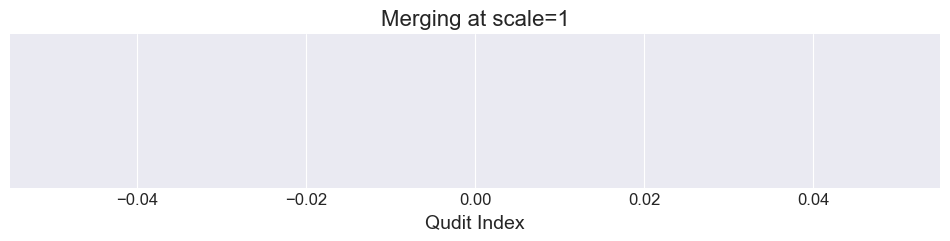

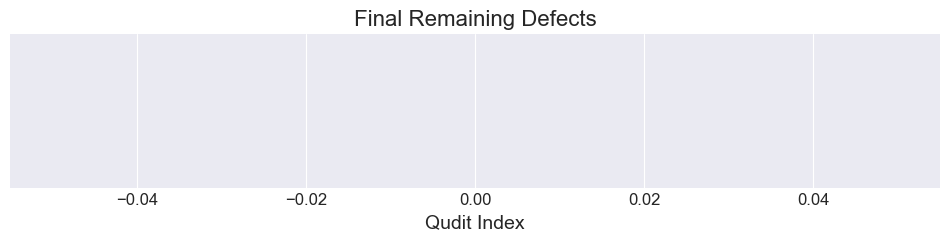

In [175]:
# 73

# Example syndrome for visualization (random).
example_syndrome = [0,1,2,0,2,1]

# Visualize HDRG merging steps.
visualize_hdrg_decoding(example_syndrome, n=7, d=3)

In [176]:
# 74

# This "master orchestrator" can run ANY experiment configuration.
# You give it: qudit dimension list, code distances, noise types, p-range, rounds.
# It returns a giant organized result dictionary.

def run_all_experiments(d_list, n_list, noise_types, p_values, rounds):
    # I create a master dictionary to store everything.
    all_exp = {}

    # Loop through all qudit dimensions.
    for d in d_list:
        print(f"\n=== Running experiments for qudit dimension d={d} ===")
        all_exp[d] = {}

        # Loop through code distances.
        for n in n_list:
            print(f"  --> Running code distance n={n}")
            all_exp[d][n] = {}

            # Loop through noise types.
            for noise in noise_types:
                print(f"     * Noise type: {noise}")

                # Run Monte-Carlo experiment across p values.
                phys, logical = monte_carlo_sweep(
                    logical_value=0,
                    n=n,
                    d=d,
                    noise_type=noise,
                    p_values=p_values,
                    trials=rounds
                )

                # Store results inside nested dictionary.
                all_exp[d][n][noise] = {
                    "physical_noise": phys,
                    "logical_error": logical
                }

    return all_exp

In [177]:
# 75

# This function merges multiple results JSON files into one combined dataset.
# Useful if you run experiments in separate notebook sessions.

def merge_results(file_list, output_filename):
    merged = {}

    # Loop through the list of filenames to merge.
    for file in file_list:
        print(f"Merging file: {file}")

        # Load individual results.
        data = load_results_json(file)

        # Merge nested dictionary structure.
        for d, n_dict in data.items():
            if d not in merged:
                merged[d] = {}

            for n, noise_dict in n_dict.items():
                if n not in merged[d]:
                    merged[d][n] = {}

                for noise_type, vals in noise_dict.items():
                    merged[d][n][noise_type] = vals  # overwrite or update

    # Save combined result file.
    save_results_json(merged, output_filename)

    print(f"Final merged file saved as: {output_filename}.json")

In [178]:
# 76

# This helper function generates a random valid syndrome vector.
# It is useful for testing decoders independently of the noise model.

def generate_random_syndrome(n, d):
    # Syndrome length is n-1.
    length = n - 1

    # I randomly choose values in 0..d-1.
    syndrome = [np.random.randint(0, d) for _ in range(length)]

    # Return random syndrome.
    return syndrome

In [179]:
# 77

# This function randomly chooses a logical value and tests decoding success.
# Helps verify general correctness of implementation.

def random_logical_test(n, d, noise_type, p):
    # Randomly choose logical value from 0..d-1.
    logical_value = np.random.randint(0, d)

    # Run a single QEC round.
    success = simulate_qec_round(logical_value, n, d, noise_type, p)

    # Print outcome.
    if success:
        print(f"Logical value {logical_value} recovered successfully.")
    else:
        print(f"Logical value {logical_value} FAILED to recover.")

In [180]:
# 78

# This function runs a stress-test where noise p increases until the code totally fails.
def noise_stress_test(n, d, noise_type, max_p=0.5, step=0.05, trials=100):
    p_values = np.arange(0, max_p + step, step)
    failure_probs = []

    for p in p_values:
        print(f"Stress testing at p={p:.2f}")

        # Compute logical error at this p.
        L = monte_carlo_logical_error(
            logical_value=0,
            n=n,
            d=d,
            noise_type=noise_type,
            p=p,
            trials=trials
        )

        failure_probs.append(L)

    return p_values, failure_probs

In [181]:
# 79

# This function plots the stress test curve.
def plot_stress_test(p_values, L_values, n, d, noise_type):
    plt.figure(figsize=(10,6))

    plt.plot(p_values, L_values, marker='o')
    plt.title(f"Stress Test — n={n}, d={d}, noise={noise_type}")
    plt.xlabel("Noise Probability p")
    plt.ylabel("Logical Error Probability")
    plt.grid(True)
    plt.show()

Stress testing at p=0.00
Stress testing at p=0.05
Stress testing at p=0.10
Stress testing at p=0.15
Stress testing at p=0.20
Stress testing at p=0.25
Stress testing at p=0.30
Stress testing at p=0.35
Stress testing at p=0.40
Stress testing at p=0.45
Stress testing at p=0.50


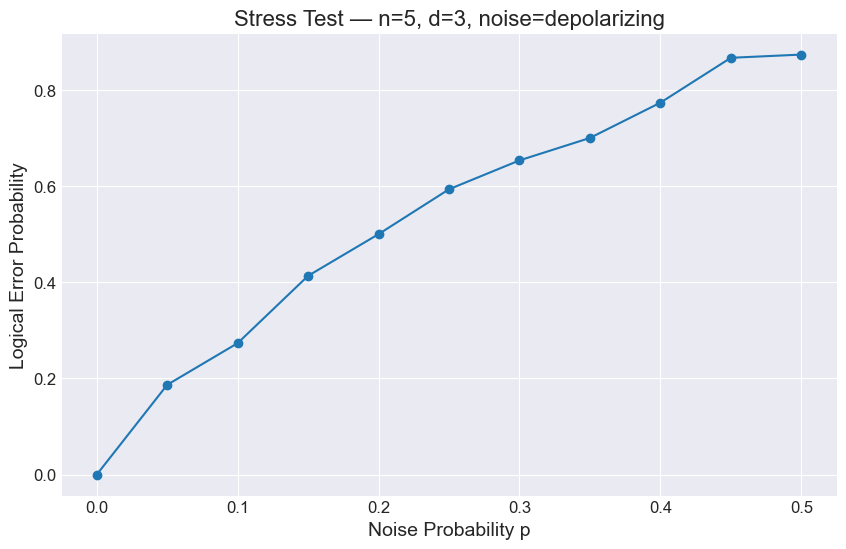

In [182]:
# 80

# Example stress test for n=5, d=3 qudit.
n = 5
d = 3
noise_type = "depolarizing"

# Run stress test.
p_vals, L_vals = noise_stress_test(n, d, noise_type, max_p=0.5, step=0.05, trials=150)

# Plot results.
plot_stress_test(p_vals, L_vals, n, d, noise_type)

In [183]:
# 81

# This function defines a nicer plot style using Matplotlib settings.
def apply_pretty_style():
    plt.style.use("seaborn-v0_8-darkgrid")  # use nicer grid style
    plt.rcParams["figure.figsize"] = (10,6) # default figure size
    plt.rcParams["font.size"] = 12          # readable text
    plt.rcParams["axes.labelsize"] = 14
    plt.rcParams["axes.titlesize"] = 16
    plt.rcParams["legend.fontsize"] = 12
    print("Pretty plot style applied.")

# Apply it.
apply_pretty_style()

Pretty plot style applied.


In [184]:
# 82 

# This function runs a condensed summary of major experiments.
def run_final_summary():
    print("\n=== FINAL SUMMARY EXPERIMENT RUN ===")

    # Parameters for quick summary.
    n = 5
    d = 3
    noise_type = "depolarizing"
    p_values = np.linspace(0.0, 0.25, 6)
    rounds = 150

    # 1. Threshold curve.
    print("\n[1] Running threshold curve...")
    phys, log = monte_carlo_sweep(0, n, d, noise_type, p_values, rounds)
    plot_monte_carlo_threshold(phys, log, n, d, noise_type)

    # 2. Decoder comparison.
    print("\n[2] Running decoder comparison...")
    hdrg_errors, mv_errors = compare_decoders(n, d, noise_type, p_values, rounds)
    plot_decoder_comparison(p_values, hdrg_errors, mv_errors, n, d)

    # 3. Scaling study.
    print("\n[3] Running scaling study...")
    scaling_results = compare_code_distances([3,5,7], d, noise_type, p_values, rounds)
    plot_scaling_curves(scaling_results, d, noise_type)

    print("\n=== SUMMARY COMPLETE ===")


=== FINAL SUMMARY EXPERIMENT RUN ===

[1] Running threshold curve...
Running Monte Carlo test at p=0.000
  -> logical error: 0.0000
Running Monte Carlo test at p=0.050
  -> logical error: 0.1467
Running Monte Carlo test at p=0.100
  -> logical error: 0.3667
Running Monte Carlo test at p=0.150
  -> logical error: 0.3867
Running Monte Carlo test at p=0.200
  -> logical error: 0.5600
Running Monte Carlo test at p=0.250
  -> logical error: 0.5867


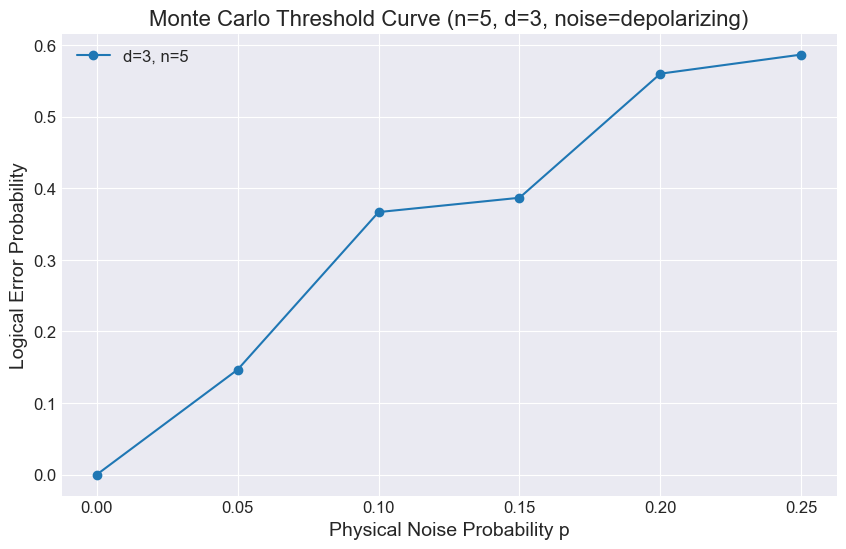


[2] Running decoder comparison...
Running decoder comparison for p=0.000
Running decoder comparison for p=0.050
Running decoder comparison for p=0.100
Running decoder comparison for p=0.150
Running decoder comparison for p=0.200
Running decoder comparison for p=0.250


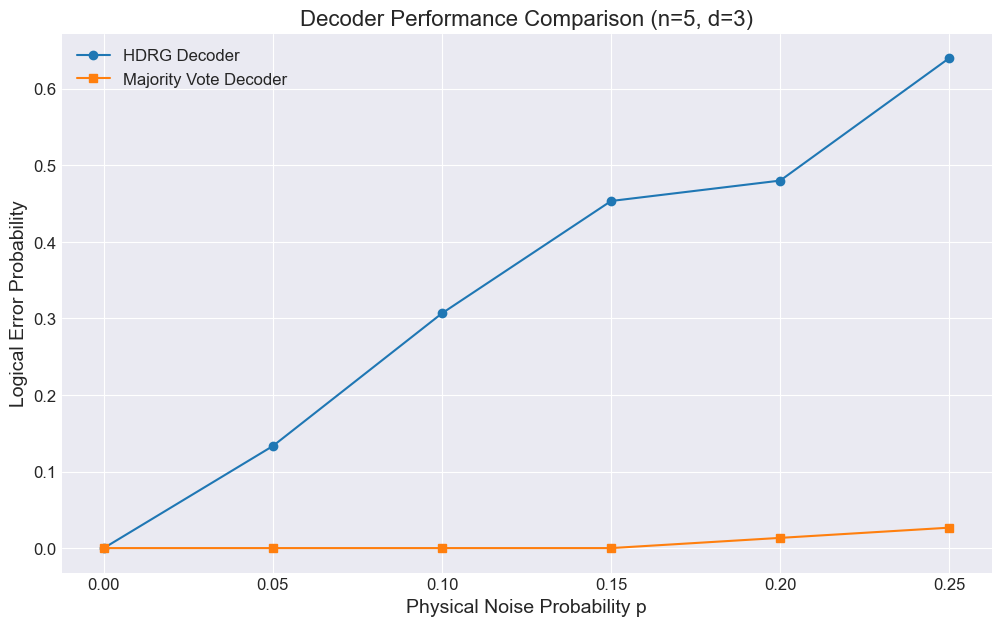


[3] Running scaling study...

--- Running scaling study for code distance n=3 ---
Noise p=0.000, Logical error=0.0000
Noise p=0.050, Logical error=0.0933
Noise p=0.100, Logical error=0.2333
Noise p=0.150, Logical error=0.3333
Noise p=0.200, Logical error=0.3400
Noise p=0.250, Logical error=0.3467

--- Running scaling study for code distance n=5 ---
Noise p=0.000, Logical error=0.0000
Noise p=0.050, Logical error=0.1333
Noise p=0.100, Logical error=0.2600
Noise p=0.150, Logical error=0.3800
Noise p=0.200, Logical error=0.4867
Noise p=0.250, Logical error=0.5467

--- Running scaling study for code distance n=7 ---
Noise p=0.000, Logical error=0.0000
Noise p=0.050, Logical error=0.2533
Noise p=0.100, Logical error=0.3467
Noise p=0.150, Logical error=0.4867
Noise p=0.200, Logical error=0.6067
Noise p=0.250, Logical error=0.7333


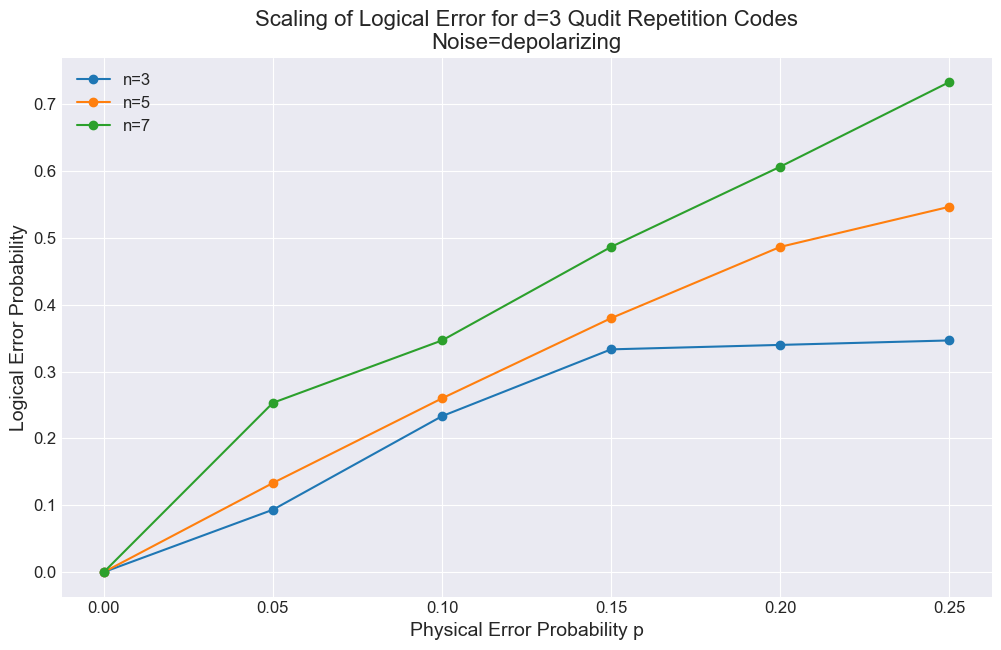


=== SUMMARY COMPLETE ===


In [185]:
# 83 

# Running this cell generates all main plots in one go.
run_final_summary()

In [186]:
# 84 

# This function clears all stored results, plots, and temp files if needed.
def cleanup_project_files():
    folders = ["results", "plots"]
    for f in folders:
        if os.path.exists(f):
            for file in os.listdir(f):
                os.remove(os.path.join(f, file))
            print(f"Cleared folder: {f}")

# You can call cleanup_project_files() if needed.